# COSC2671 Social Media and Network Analytics — Assignment 2
## YouTube Comment Network + NLP Analysis: 2025 Australian Formula 1 Grand Prix

**Graoup 37**  
**Topic:** Australian Grand Prix 2025 YouTube fan communities  

---

## Research Question

> **How do fan communities form on YouTube around the 2025 Australian Grand Prix, who are the most influential voices, and does a commenter's position in the network predict their sentiment?**

---

## What this notebook does

This notebook is designed to be **fully independent**. It does not require the separate `.py` files to run.

The workflow is:

1. Search YouTube for around **30 public videos** about the 2025 Australian Grand Prix.
2. Download **all available top-level comments** for each selected video using pagination.
3. Download **all available replies** to each top-level comment using the `comments.list(parentId=...)` endpoint.
4. Flatten the raw JSON into a tabular comment dataset.
5. Preprocess comment text.
6. Perform VADER sentiment analysis.
7. Perform topic modelling and word-frequency analysis.
8. Build YouTube user networks:
   - **Directed reply network**: user A replied to user B.
   - **Undirected co-comment network**: users who commented on the same video.
   - **User-video bipartite network**: users connected to videos they commented on.
9. Compute centrality, communities, homophily, and diffusion-style simulations using lab-style NetworkX methods.
10. Export report-ready CSV files, figures, and GraphML files.

---

## Important ethical and access notes

- Do **not** put your API key inside this notebook before submission.
- Use an environment variable named `YOUTUBE_API_KEY`, or paste it into the hidden prompt when running locally.
- YouTube usernames are public, but this notebook creates pseudonymous `User_000001` labels for report tables and network graphs.
- The API can only collect comments that are public and accessible. Videos with comments disabled, private videos, deleted videos, or API-restricted videos are skipped and logged.

## Section 1 — Setup and Configuration

Run this cell first. If a package is missing, install it using the commented `%pip install` line, then restart the kernel.

In [1]:
# Uncomment only if your environment is missing packages.
# %pip install google-api-python-client pandas numpy matplotlib networkx nltk scikit-learn wordcloud langdetect scipy pyLDAvis python-louvain

import os
import re
import json
import time
import math
import getpass
import hashlib
import random
import warnings
from pathlib import Path
from collections import defaultdict, Counter
from itertools import combinations
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from scipy import stats as sp_stats

import nltk
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except Exception:
    WORDCLOUD_AVAILABLE = False

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

# Folder structure
DATA_DIR = Path('data')
OUT_DIR = Path('outputs')
FIG_DIR = OUT_DIR / 'figures'
TABLE_DIR = OUT_DIR / 'tables'
GRAPH_DIR = OUT_DIR / 'graphs'
LOG_DIR = OUT_DIR / 'logs'

for d in [DATA_DIR, OUT_DIR, FIG_DIR, TABLE_DIR, GRAPH_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# NLTK resources. This is safe to run repeatedly.
for pkg in ['stopwords', 'vader_lexicon', 'punkt']:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as e:
        print(f'NLTK download warning for {pkg}: {e}')

print('Setup complete.')
print(f'pandas    : {pd.__version__}')
print(f'numpy     : {np.__version__}')
print(f'networkx  : {nx.__version__}')
print(f'wordcloud : {WORDCLOUD_AVAILABLE}')

Setup complete.
pandas    : 2.2.2
numpy     : 1.26.4
networkx  : 3.3
wordcloud : True


## Section 2 — Live YouTube Data Collection

This section collects the real dataset. It searches for approximately **30 videos** and downloads all available comments and replies.

### Why two comment endpoints are used

`commentThreads.list` retrieves top-level comment threads for a video. The inline `replies` field may contain only a subset of replies, so this notebook separately calls `comments.list(parentId=top_level_comment_id)` to collect all available replies to each top-level comment.

### Default collection settings

- `TARGET_VIDEO_COUNT = 30`
- `MAX_TOP_LEVEL_COMMENT_PAGES_PER_VIDEO = None` means no page cap.
- `MAX_REPLY_PAGES_PER_COMMENT = None` means no reply page cap.
- `COLLECT_REPLIES = True`

If the API quota is exhausted, the checkpoint files in `data/` keep the partial progress.

In [2]:
# =============================
# Live collection configuration
# =============================

RUN_LIVE_COLLECTION = True          # Keep True when you want the notebook to download real YouTube data.
FORCE_RECOLLECT = False             # Set True to ignore existing raw JSON and collect again.
TARGET_VIDEO_COUNT = 30             # Target number of deduplicated videos.
COLLECT_REPLIES = True              # Fetch all available replies to top-level comments.

# None means "all available pages". Use a number only if you need to test quickly or avoid quota exhaustion.
MAX_TOP_LEVEL_COMMENT_PAGES_PER_VIDEO = None
MAX_REPLY_PAGES_PER_COMMENT = None

# Search queries. These are intentionally overlapping; videos are deduplicated by videoId.
SEARCH_QUERIES = [
    'Australian Grand Prix 2025 F1',
    '2025 Australian GP race highlights',
    'Melbourne Grand Prix 2025 Formula 1',
    'Albert Park Grand Prix 2025 F1',
    'Oscar Piastri Australian GP 2025',
    'Lando Norris Australian Grand Prix 2025',
    'Max Verstappen Australian GP 2025',
    'Ferrari Australian Grand Prix 2025',
]

# Search date range. These can be loosened if you want later reaction videos too.
SEARCH_PUBLISHED_AFTER = '2025-03-01T00:00:00Z'
SEARCH_PUBLISHED_BEFORE = '2025-12-31T23:59:59Z'

RAW_JSON_PATH = DATA_DIR / 'agp2025_youtube_30videos_all_comments_raw.json'
FLAT_CSV_PATH = DATA_DIR / 'agp2025_youtube_30videos_all_comments_flat.csv'
CHECKPOINT_PATH = DATA_DIR / 'agp2025_youtube_collection_checkpoint.json'
ERROR_LOG_PATH = LOG_DIR / 'youtube_collection_errors.json'

print('Collection target:')
print(f'  Videos target          : {TARGET_VIDEO_COUNT}')
print(f'  Collect replies        : {COLLECT_REPLIES}')
print(f'  Top-level page cap     : {MAX_TOP_LEVEL_COMMENT_PAGES_PER_VIDEO}')
print(f'  Reply page cap         : {MAX_REPLY_PAGES_PER_COMMENT}')
print(f'  Raw output             : {RAW_JSON_PATH}')

Collection target:
  Videos target          : 30
  Collect replies        : True
  Top-level page cap     : None
  Reply page cap         : None
  Raw output             : data/agp2025_youtube_30videos_all_comments_raw.json


In [3]:
def get_youtube_api_key():
    """Read YouTube API key from environment variable or hidden prompt. Never hard-code the key."""
    api_key = os.environ.get('YOUTUBE_API_KEY', '').strip()
    if api_key:
        return api_key
    print('YOUTUBE_API_KEY environment variable was not found.')
    print('Paste your YouTube Data API key below. It will not be printed or saved in the notebook.')
    api_key = getpass.getpass('YouTube API key: ').strip()
    if not api_key:
        raise ValueError('No YouTube API key provided. Set YOUTUBE_API_KEY or paste it into the prompt.')
    return api_key


def build_youtube_client(api_key):
    """Create a YouTube Data API v3 client."""
    try:
        from googleapiclient.discovery import build
    except ImportError as e:
        raise ImportError('google-api-python-client is required. Run: %pip install google-api-python-client') from e
    return build('youtube', 'v3', developerKey=api_key)


def safe_int(value, default=0):
    try:
        return int(value)
    except Exception:
        return default


def iso_now():
    return datetime.utcnow().replace(microsecond=0).isoformat() + 'Z'

print('YouTube client helper functions ready.')

YouTube client helper functions ready.


In [4]:
def execute_youtube_request(request, context, error_log, sleep_seconds=0.05):
    """Execute a YouTube API request with basic error logging."""
    try:
        response = request.execute()
        if sleep_seconds:
            time.sleep(sleep_seconds)
        return response
    except Exception as e:
        error_log.append({
            'time': iso_now(),
            'context': context,
            'error_type': type(e).__name__,
            'error': str(e)[:1000]
        })
        return None


def search_youtube_videos(youtube, queries, target_count=30, error_log=None):
    """
    Search YouTube for videos across multiple queries and deduplicate by videoId.
    Returns a list of videoIds and a metadata dict.
    """
    if error_log is None:
        error_log = []

    videos = {}

    for query in queries:
        print(f'\nSearching query: {query}')
        page_token = None

        while len(videos) < target_count:
            req = youtube.search().list(
                part='snippet',
                q=query,
                type='video',
                order='relevance',
                maxResults=50,
                publishedAfter=SEARCH_PUBLISHED_AFTER,
                publishedBefore=SEARCH_PUBLISHED_BEFORE,
                pageToken=page_token
            )
            resp = execute_youtube_request(req, f'search query={query}', error_log)
            if not resp:
                break

            for item in resp.get('items', []):
                video_id = item.get('id', {}).get('videoId')
                snippet = item.get('snippet', {})
                if not video_id:
                    continue
                if video_id not in videos:
                    videos[video_id] = {
                        'videoId': video_id,
                        'title': snippet.get('title', ''),
                        'channelTitle': snippet.get('channelTitle', ''),
                        'channelId': snippet.get('channelId', ''),
                        'publishedAt': snippet.get('publishedAt', ''),
                        'description': snippet.get('description', ''),
                        'searchQueryMatched': query
                    }
                    print(f"  {len(videos):02d}. {videos[video_id]['title'][:85]}")
                    if len(videos) >= target_count:
                        break

            page_token = resp.get('nextPageToken')
            if not page_token:
                break

        if len(videos) >= target_count:
            break

    return list(videos.keys())[:target_count], {vid: videos[vid] for vid in list(videos.keys())[:target_count]}


def enrich_video_metadata(youtube, video_ids, video_meta, error_log=None):
    """Add statistics/contentDetails for the selected videos."""
    if error_log is None:
        error_log = []

    for i in range(0, len(video_ids), 50):
        batch = video_ids[i:i+50]
        req = youtube.videos().list(
            part='snippet,statistics,contentDetails',
            id=','.join(batch),
            maxResults=50
        )
        resp = execute_youtube_request(req, f'videos.list batch={i//50}', error_log)
        if not resp:
            continue

        for item in resp.get('items', []):
            vid = item.get('id')
            stats = item.get('statistics', {})
            snippet = item.get('snippet', {})
            content = item.get('contentDetails', {})
            video_meta.setdefault(vid, {})
            video_meta[vid].update({
                'videoId': vid,
                'title': snippet.get('title', video_meta[vid].get('title', '')),
                'channelTitle': snippet.get('channelTitle', video_meta[vid].get('channelTitle', '')),
                'channelId': snippet.get('channelId', video_meta[vid].get('channelId', '')),
                'publishedAt': snippet.get('publishedAt', video_meta[vid].get('publishedAt', '')),
                'duration': content.get('duration', ''),
                'viewCount': safe_int(stats.get('viewCount')),
                'likeCount': safe_int(stats.get('likeCount')),
                'commentCount': safe_int(stats.get('commentCount')),
            })

    return video_meta

print('Video search functions ready.')

Video search functions ready.


In [5]:
def parse_top_level_comment(thread_item, video_meta):
    """Convert a commentThread item into a flat top-level comment record."""
    thread_snippet = thread_item.get('snippet', {})
    top = thread_snippet.get('topLevelComment', {})
    top_id = top.get('id', '')
    top_snippet = top.get('snippet', {})
    author_channel = top_snippet.get('authorChannelId', {}) or {}

    return {
        'comment_id': top_id,
        'parent_id': None,
        'is_reply': False,
        'relation_type': 'top_level',
        'videoId': video_meta.get('videoId', ''),
        'video_title': video_meta.get('title', ''),
        'video_channel': video_meta.get('channelTitle', ''),
        'video_publishedAt': video_meta.get('publishedAt', ''),
        'video_viewCount': video_meta.get('viewCount', 0),
        'video_likeCount': video_meta.get('likeCount', 0),
        'video_commentCount_reported': video_meta.get('commentCount', 0),
        'author': top_snippet.get('authorDisplayName', ''),
        'author_channel_id': author_channel.get('value', ''),
        'text': top_snippet.get('textDisplay', ''),
        'publishedAt': top_snippet.get('publishedAt', ''),
        'updatedAt': top_snippet.get('updatedAt', ''),
        'likeCount': safe_int(top_snippet.get('likeCount')),
        'totalReplyCount': safe_int(thread_snippet.get('totalReplyCount')),
        'parent_author': None,
        'parent_author_channel_id': None,
    }


def parse_reply_comment(reply_item, video_meta, parent_comment):
    """Convert a comments.list reply item into a flat reply comment record."""
    reply_id = reply_item.get('id', '')
    snip = reply_item.get('snippet', {})
    author_channel = snip.get('authorChannelId', {}) or {}

    return {
        'comment_id': reply_id,
        'parent_id': parent_comment.get('comment_id'),
        'is_reply': True,
        'relation_type': 'reply',
        'videoId': video_meta.get('videoId', ''),
        'video_title': video_meta.get('title', ''),
        'video_channel': video_meta.get('channelTitle', ''),
        'video_publishedAt': video_meta.get('publishedAt', ''),
        'video_viewCount': video_meta.get('viewCount', 0),
        'video_likeCount': video_meta.get('likeCount', 0),
        'video_commentCount_reported': video_meta.get('commentCount', 0),
        'author': snip.get('authorDisplayName', ''),
        'author_channel_id': author_channel.get('value', ''),
        'text': snip.get('textDisplay', ''),
        'publishedAt': snip.get('publishedAt', ''),
        'updatedAt': snip.get('updatedAt', ''),
        'likeCount': safe_int(snip.get('likeCount')),
        'totalReplyCount': 0,
        'parent_author': parent_comment.get('author'),
        'parent_author_channel_id': parent_comment.get('author_channel_id'),
    }


def fetch_all_replies_for_comment(youtube, video_meta, parent_comment, error_log=None):
    """Fetch all available replies for a top-level comment using comments.list(parentId=...)."""
    if error_log is None:
        error_log = []
    replies = []
    parent_id = parent_comment.get('comment_id')
    if not parent_id:
        return replies

    page_token = None
    page_no = 0

    while True:
        page_no += 1
        req = youtube.comments().list(
            part='snippet',
            parentId=parent_id,
            maxResults=100,
            textFormat='plainText',
            pageToken=page_token
        )
        resp = execute_youtube_request(req, f'comments.list parentId={parent_id}', error_log)
        if not resp:
            break

        for reply_item in resp.get('items', []):
            replies.append(parse_reply_comment(reply_item, video_meta, parent_comment))

        page_token = resp.get('nextPageToken')
        if not page_token:
            break
        if MAX_REPLY_PAGES_PER_COMMENT is not None and page_no >= MAX_REPLY_PAGES_PER_COMMENT:
            break

    return replies


def fetch_all_comments_for_video(youtube, video_meta, error_log=None):
    """
    Fetch all available top-level comments and, optionally, all replies for one video.
    """
    if error_log is None:
        error_log = []

    video_id = video_meta['videoId']
    comments = []
    page_token = None
    page_no = 0
    top_count = 0
    reply_count = 0

    while True:
        page_no += 1
        req = youtube.commentThreads().list(
            part='snippet',
            videoId=video_id,
            order='time',
            maxResults=100,
            textFormat='plainText',
            pageToken=page_token
        )
        resp = execute_youtube_request(req, f'commentThreads.list videoId={video_id}', error_log)
        if not resp:
            break

        for thread_item in resp.get('items', []):
            top_comment = parse_top_level_comment(thread_item, video_meta)
            comments.append(top_comment)
            top_count += 1

            if COLLECT_REPLIES and top_comment.get('totalReplyCount', 0) > 0:
                replies = fetch_all_replies_for_comment(youtube, video_meta, top_comment, error_log)
                comments.extend(replies)
                reply_count += len(replies)

        if page_no % 5 == 0:
            print(f'    page {page_no:03d}: top-level={top_count}, replies={reply_count}, total={len(comments)}')

        page_token = resp.get('nextPageToken')
        if not page_token:
            break
        if MAX_TOP_LEVEL_COMMENT_PAGES_PER_VIDEO is not None and page_no >= MAX_TOP_LEVEL_COMMENT_PAGES_PER_VIDEO:
            break

    return comments, {'top_level_comments': top_count, 'replies': reply_count, 'total_comments': len(comments), 'pages': page_no}

print('Comment collection functions ready.')

Comment collection functions ready.


In [6]:
def save_collection_checkpoint(collection):
    with open(CHECKPOINT_PATH, 'w', encoding='utf-8') as f:
        json.dump(collection, f, ensure_ascii=False, indent=2)


def collect_youtube_dataset():
    """Full live collection: search 30 videos, collect all available comments/replies, save JSON/CSV."""
    error_log = []
    api_key = get_youtube_api_key()
    youtube = build_youtube_client(api_key)

    print('Starting live YouTube data collection...')
    video_ids, video_meta = search_youtube_videos(
        youtube,
        SEARCH_QUERIES,
        target_count=TARGET_VIDEO_COUNT,
        error_log=error_log
    )
    video_meta = enrich_video_metadata(youtube, video_ids, video_meta, error_log=error_log)

    print(f'\nSelected {len(video_ids)} unique videos for comment collection.')

    collection = {
        'collection_metadata': {
            'created_at_utc': iso_now(),
            'target_video_count': TARGET_VIDEO_COUNT,
            'actual_video_count': len(video_ids),
            'search_queries': SEARCH_QUERIES,
            'search_published_after': SEARCH_PUBLISHED_AFTER,
            'search_published_before': SEARCH_PUBLISHED_BEFORE,
            'collect_replies': COLLECT_REPLIES,
            'max_top_level_comment_pages_per_video': MAX_TOP_LEVEL_COMMENT_PAGES_PER_VIDEO,
            'max_reply_pages_per_comment': MAX_REPLY_PAGES_PER_COMMENT,
            'note': 'API key is not stored. Comments are public YouTube comments accessible via YouTube Data API.'
        },
        'videos': [],
        'errors': error_log
    }

    for idx, vid in enumerate(video_ids, start=1):
        meta = video_meta[vid]
        print('\n' + '='*90)
        print(f'Video {idx}/{len(video_ids)}: {meta.get("title", "")[:100]}')
        print(f'videoId={vid} | channel={meta.get("channelTitle", "")} | reported comments={meta.get("commentCount", 0)}')

        comments, counts = fetch_all_comments_for_video(youtube, meta, error_log=error_log)
        video_record = dict(meta)
        video_record['comments'] = comments
        video_record['collection_counts'] = counts
        collection['videos'].append(video_record)
        collection['errors'] = error_log

        print(f'  collected top-level={counts["top_level_comments"]}, replies={counts["replies"]}, total={counts["total_comments"]}')
        save_collection_checkpoint(collection)

    with open(RAW_JSON_PATH, 'w', encoding='utf-8') as f:
        json.dump(collection, f, ensure_ascii=False, indent=2)

    flat_df = flatten_youtube_collection(collection)
    flat_df.to_csv(FLAT_CSV_PATH, index=False, encoding='utf-8')

    with open(ERROR_LOG_PATH, 'w', encoding='utf-8') as f:
        json.dump(error_log, f, ensure_ascii=False, indent=2)

    print('\nCollection complete.')
    print(f'  Raw JSON saved : {RAW_JSON_PATH}')
    print(f'  Flat CSV saved : {FLAT_CSV_PATH}')
    print(f'  Error log saved: {ERROR_LOG_PATH}')
    print(f'  Total comments : {len(flat_df)}')
    return collection, flat_df


def flatten_youtube_collection(collection):
    """Flatten nested video/comment JSON into a DataFrame."""
    rows = []
    for video in collection.get('videos', []):
        for c in video.get('comments', []):
            rows.append(c)
    df = pd.DataFrame(rows)
    return df

print('Collection wrapper ready.')

Collection wrapper ready.


In [7]:
# ==============================================================
# Run or load data collection
# ============================================================== 

if RUN_LIVE_COLLECTION and (FORCE_RECOLLECT or not RAW_JSON_PATH.exists()):
    collection, df_raw = collect_youtube_dataset()
elif RAW_JSON_PATH.exists():
    print(f'Loading existing raw YouTube dataset: {RAW_JSON_PATH}')
    with open(RAW_JSON_PATH, 'r', encoding='utf-8') as f:
        collection = json.load(f)
    df_raw = flatten_youtube_collection(collection)
    if not FLAT_CSV_PATH.exists():
        df_raw.to_csv(FLAT_CSV_PATH, index=False, encoding='utf-8')
else:
    raise FileNotFoundError(
        'No raw dataset found and RUN_LIVE_COLLECTION is False. '
        'Set RUN_LIVE_COLLECTION=True and provide YOUTUBE_API_KEY, or place the raw JSON in data/.'
    )

print('\nRaw dataset summary')
print(f'  videos      : {len(collection.get("videos", []))}')
print(f'  comments    : {len(df_raw)}')
print(f'  replies     : {int(df_raw["is_reply"].sum()) if "is_reply" in df_raw.columns and len(df_raw) else 0}')
print(f'  unique users: {df_raw["author"].nunique() if "author" in df_raw.columns and len(df_raw) else 0}')

df_raw.head(3)

YOUTUBE_API_KEY environment variable was not found.
Paste your YouTube Data API key below. It will not be printed or saved in the notebook.


YouTube API key:  ········


Starting live YouTube data collection...

Searching query: Australian Grand Prix 2025 F1
  01. Race Highlights | 2025 Australian Grand Prix
  02. Radio Rewind | 2025 Australian Grand Prix | Paramount+
  03. Qualifying Highlights | 2025 Australian Grand Prix
  04. Melbourne Mayhem! 🇦🇺 Who Survived the Aussie GP 2025? 🔥 #f1 #shorts #formula1
  05. How the Australian F1 Track is Built
  06. When the Track Is Wet, It Is No Longer Dry 🙂‍↕️😉
  07. Live reaction to Australian GP qualifying 😮
  08. Fans React to the 2025 Australian Grand Prix
  09. Lando Norris&#39; Pole Lap | 2025 Australian Grand Prix | Pirelli
  10. COST OF ATTENDING THE AUS GP
  11. Formula 1: Australian Grand Prix | FULL HIGHLIGHTS
  12. INSIDE STORY: Norris Masters Melbourne Rainfall | 2025 Australian Grand Prix | Lenovo
  13. How to MASTER AUSTRALIA on F125! | Track Guide + Setup
  14. FP1 Highlights | 2025 Australian Grand Prix
  15. Heartbreak For Piastri 💔
  16. EVERY Grand Prix Highlight of the 2025 F1 Season
  17. 

,comment_id,parent_id,is_reply,relation_type,videoId,video_title,video_channel,video_publishedAt,video_viewCount,video_likeCount,video_commentCount_reported,author,author_channel_id,text,publishedAt,updatedAt,likeCount,totalReplyCount,parent_author,parent_author_channel_id
0,UgypNY7nUualdA2hB1d4AaABAg,None,False,top_level,md9-jG4RzXs,Race Highlights | 2025 Australian Grand Prix,FORMULA 1,2025-03-16T07:38:24Z,15375849,265022,9654,@Formula1,UCB_qr75-ydFVKSF9Dmo6izg,UPDATE: Kimi Antonelli has been re-instated in...,2025-03-16T09:06:36Z,2025-03-16T09:06:36Z,18213,150,None,None
1,UgypNY7nUualdA2hB1d4AaABAg.AFinfGPsiSgAFinjJoMcBp,UgypNY7nUualdA2hB1d4AaABAg,True,reply,md9-jG4RzXs,Race Highlights | 2025 Australian Grand Prix,FORMULA 1,2025-03-16T07:38:24Z,15375849,265022,9654,@manchester유나이티드,UCYzlhBFt5aA5huuCREpXCvQ,OK 🎉🎉,2025-03-16T09:07:09Z,2025-03-16T09:07:09Z,153,0,@Formula1,UCB_qr75-ydFVKSF9Dmo6izg
2,UgypNY7nUualdA2hB1d4AaABAg.AFinfGPsiSgAFinkzkc_Vh,UgypNY7nUualdA2hB1d4AaABAg,True,reply,md9-jG4RzXs,Race Highlights | 2025 Australian Grand Prix,FORMULA 1,2025-03-16T07:38:24Z,15375849,265022,9654,@montyx2333,UCbrUCUtJZP9UVjikD9URidQ,Kimi my goat 🙏,2025-03-16T09:07:23Z,2025-03-16T09:07:23Z,201,0,@Formula1,UCB_qr75-ydFVKSF9Dmo6izg


## Section 3 — Data Quality Checks and Preprocessing

This section prepares the raw comments for NLP and network analysis.

Main steps:

1. Keep comments with usable text.
2. Clean URLs, punctuation noise, and repeated spacing.
3. Create pseudonymous user IDs.
4. Keep both top-level comments and replies.
5. Export a representative sample under 10 MB for submission.

In [8]:
def is_agp_relevant_title(title):
    """Conservative keyword filter to remove unrelated search results."""
    t = str(title).lower()
    keywords = [
        'australian grand prix', 'australian gp', 'australia gp', 'melbourne',
        'albert park', 'f1 2025', 'formula 1 2025', 'piastri', 'norris', 'verstappen', 'leclerc', 'hamilton'
    ]
    return any(k in t for k in keywords)


def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'&amp;', '&', text)
    text = re.sub(r'&quot;', '"', text)
    text = re.sub(r'&#39;', "'", text)
    text = re.sub(r'[^A-Za-z0-9\s\'\-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()


def make_stable_alias(series):
    """Create stable User_XXXXXX aliases from channel IDs/display names."""
    unique_vals = sorted(pd.Series(series).fillna('unknown').astype(str).unique())
    mapping = {val: f'User_{i+1:06d}' for i, val in enumerate(unique_vals)}
    return mapping


def author_key(row):
    channel_id = str(row.get('author_channel_id', '') or '').strip()
    author = str(row.get('author', '') or '').strip()
    return channel_id if channel_id else author


def preprocess_comments(df):
    df = df.copy()

    if df.empty:
        raise ValueError('The raw comment DataFrame is empty. Check the API collection output.')

    # Standardise fields.
    for col in ['text', 'author', 'author_channel_id', 'video_title', 'videoId', 'publishedAt']:
        if col not in df.columns:
            df[col] = ''

    df['text'] = df['text'].fillna('').astype(str)
    df = df[df['text'].str.strip().str.len() > 0].copy()

    # Keep relevant video titles only. If filtering removes everything, fall back to all collected comments.
    before = len(df)
    title_mask = df['video_title'].apply(is_agp_relevant_title)
    if title_mask.sum() > 0:
        df = df[title_mask].copy()
    print(f'AGP title filtering: kept {len(df)} of {before} comments')

    df['clean_comment'] = df['text'].apply(clean_text)
    df = df[df['clean_comment'].str.len() >= 3].copy()

    # Parse dates safely.
    df['publishedAt_dt'] = pd.to_datetime(df['publishedAt'], errors='coerce', utc=True)
    df['date'] = df['publishedAt_dt'].dt.date

    # User identity for network analysis.
    df['user_key'] = df.apply(author_key, axis=1)
    alias_map = make_stable_alias(df['user_key'])
    df['user_alias'] = df['user_key'].map(alias_map)

    # Parent aliases for reply network.
    parent_key_map = df.set_index('comment_id')['user_key'].to_dict() if 'comment_id' in df.columns else {}
    df['parent_user_key'] = df['parent_id'].map(parent_key_map) if 'parent_id' in df.columns else None
    df['parent_user_alias'] = df['parent_user_key'].map(alias_map)

    # Ensure numeric columns.
    for col in ['likeCount', 'video_viewCount', 'video_likeCount', 'video_commentCount_reported', 'totalReplyCount']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

    return df, alias_map


df_comments, alias_map = preprocess_comments(df_raw)

CLEAN_CSV_PATH = DATA_DIR / 'agp2025_comments_clean.csv'
df_comments.to_csv(CLEAN_CSV_PATH, index=False, encoding='utf-8')

# Representative sample for submission. Keep public text, but use aliases in the report.
SAMPLE_CSV_PATH = DATA_DIR / 'representative_sample_agp2025_youtube_comments.csv'
sample_n = min(len(df_comments), 2000)
df_comments.sample(sample_n, random_state=42).to_csv(SAMPLE_CSV_PATH, index=False, encoding='utf-8')

print(f'Clean comments saved: {CLEAN_CSV_PATH}')
print(f'Representative sample saved: {SAMPLE_CSV_PATH}')
print(f'Comments after cleaning: {len(df_comments)}')
print(f'Unique videos: {df_comments["videoId"].nunique()}')
print(f'Unique users: {df_comments["user_alias"].nunique()}')
print(f'Replies: {int(df_comments["is_reply"].sum()) if "is_reply" in df_comments.columns else 0}')

df_comments[['video_title', 'user_alias', 'is_reply', 'clean_comment', 'likeCount']].head()

AGP title filtering: kept 25836 of 27744 comments
Clean comments saved: data/agp2025_comments_clean.csv
Representative sample saved: data/representative_sample_agp2025_youtube_comments.csv
Comments after cleaning: 25146
Unique videos: 20
Unique users: 19161
Replies: 7405


,video_title,user_alias,is_reply,clean_comment,likeCount
0,Race Highlights | 2025 Australian Grand Prix,User_003701,False,update kimi antonelli has been re-instated in ...,18213
2,Race Highlights | 2025 Australian Grand Prix,User_011981,True,kimi my goat,201
3,Race Highlights | 2025 Australian Grand Prix,User_002010,True,pin it,38
4,Race Highlights | 2025 Australian Grand Prix,User_010756,True,p4 amazing,42
5,Race Highlights | 2025 Australian Grand Prix,User_015429,True,hey ferrari what's your strategy in dry weathe...,95


In [9]:
# Dataset coverage table
coverage = pd.DataFrame({
    'metric': [
        'videos_collected', 'comments_total', 'top_level_comments', 'reply_comments',
        'unique_users', 'date_min', 'date_max'
    ],
    'value': [
        df_comments['videoId'].nunique(),
        len(df_comments),
        int((df_comments['is_reply'] == False).sum()) if 'is_reply' in df_comments.columns else 'N/A',
        int((df_comments['is_reply'] == True).sum()) if 'is_reply' in df_comments.columns else 'N/A',
        df_comments['user_alias'].nunique(),
        str(df_comments['publishedAt_dt'].min()),
        str(df_comments['publishedAt_dt'].max())
    ]
})
coverage.to_csv(TABLE_DIR / 'dataset_coverage.csv', index=False)
coverage

,metric,value
0,videos_collected,20
1,comments_total,25146
2,top_level_comments,17741
3,reply_comments,7405
4,unique_users,19161
5,date_min,2025-03-14 03:55:18+00:00
6,date_max,2026-05-22 04:46:56+00:00


## Section 4 — Sentiment Analysis with VADER

VADER is suitable for short social media text because it handles informal language, punctuation intensity, emojis and short comments without needing a manually-labelled training set.

Classification rule:

- compound score >= 0.05: positive
- compound score <= -0.05: negative
- otherwise: neutral

In [10]:
analyzer = SentimentIntensityAnalyzer()


def get_sentiment(text):
    text = str(text).strip()
    if not text:
        return pd.Series({'sentiment': 'neutral', 'compound_score': 0.0})
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        label = 'positive'
    elif compound <= -0.05:
        label = 'negative'
    else:
        label = 'neutral'
    return pd.Series({'sentiment': label, 'compound_score': compound})

sentiment_df = df_comments['clean_comment'].apply(get_sentiment)
df_comments = pd.concat([df_comments.drop(columns=[c for c in ['sentiment','compound_score'] if c in df_comments.columns]), sentiment_df], axis=1)

df_comments.to_csv(DATA_DIR / 'agp2025_comments_with_sentiment.csv', index=False, encoding='utf-8')

sent_counts = df_comments['sentiment'].value_counts().reindex(['positive','neutral','negative']).fillna(0).astype(int)
sent_summary = pd.DataFrame({
    'sentiment': sent_counts.index,
    'count': sent_counts.values,
    'percentage': (sent_counts.values / len(df_comments) * 100).round(2)
})
sent_summary.to_csv(TABLE_DIR / 'sentiment_summary.csv', index=False)

print('Sentiment distribution')
print(sent_summary.to_string(index=False))
print(f'Average compound score: {df_comments["compound_score"].mean():.4f}')

Sentiment distribution
sentiment  count  percentage
 positive  11295       44.92
  neutral   9366       37.25
 negative   4485       17.84
Average compound score: 0.1773


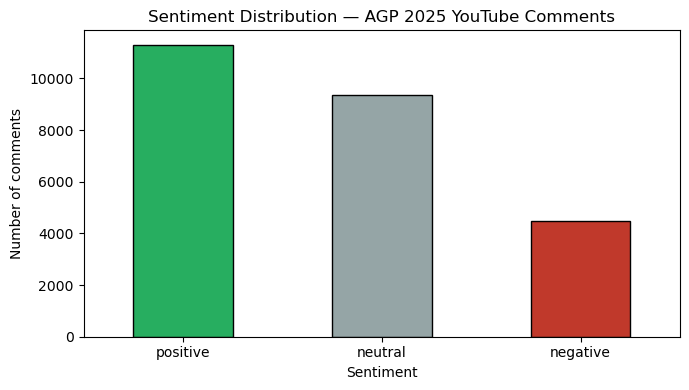

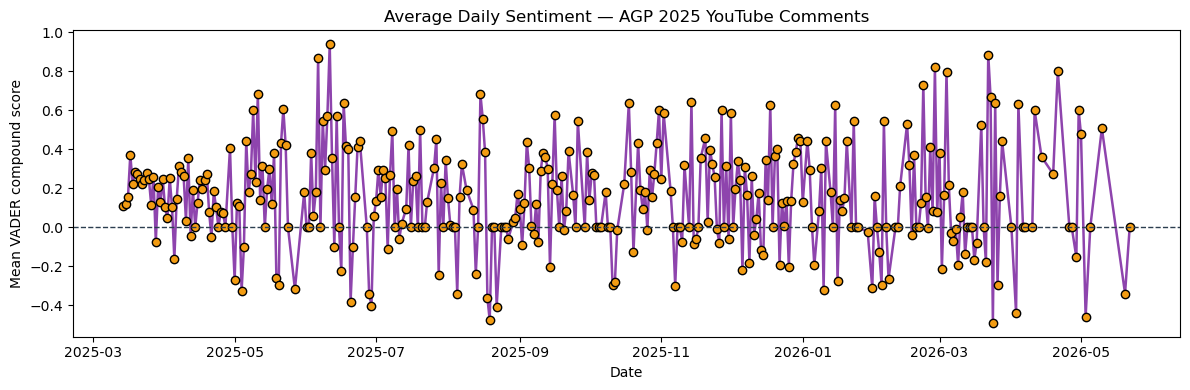

In [11]:
# Sentiment distribution plot
plt.figure(figsize=(7, 4))
sent_color_map = {'positive': '#27AE60', 'neutral': '#95A5A6', 'negative': '#C0392B'}
sent_counts.plot(kind='bar', edgecolor='black', color=[sent_color_map.get(label, '#E67E22') for label in sent_counts.index])
plt.title('Sentiment Distribution — AGP 2025 YouTube Comments')
plt.xlabel('Sentiment')
plt.ylabel('Number of comments')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'sentiment_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

# Sentiment over time
if df_comments['publishedAt_dt'].notna().sum() > 0:
    daily = df_comments.dropna(subset=['publishedAt_dt']).set_index('publishedAt_dt')['compound_score'].resample('D').mean().dropna()
    plt.figure(figsize=(12, 4))
    plt.plot(daily.index, daily.values, marker='o', linewidth=1.8, color='#8E44AD', markerfacecolor='#F39C12', markeredgecolor='black')
    plt.axhline(0, linestyle='--', linewidth=1, color='#2C3E50')
    plt.title('Average Daily Sentiment — AGP 2025 YouTube Comments')
    plt.xlabel('Date')
    plt.ylabel('Mean VADER compound score')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'sentiment_over_time.png', dpi=160, bbox_inches='tight')
    plt.show()
else:
    print('No valid dates for time-series plot.')

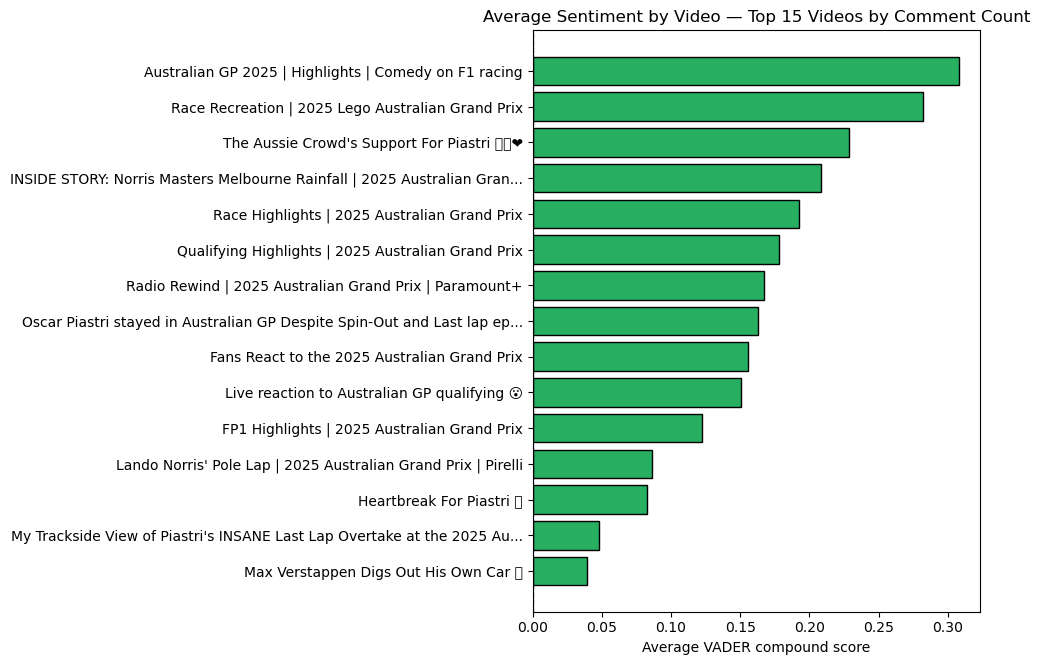

,videoId,video_title,comments,avg_sentiment
16,md9-jG4RzXs,Race Highlights | 2025 Australian Grand Prix,9581,0.192684
9,Mr7T8TC-cZg,Qualifying Highlights | 2025 Australian Grand ...,7323,0.178261
18,stF2J_SJabs,FP1 Highlights | 2025 Australian Grand Prix,2381,0.122710
0,-b3k0zApcG4,Australian GP 2025 | Highlights | Comedy on F1...,1259,0.307806
15,U77_-18yqII,Radio Rewind | 2025 Australian Grand Prix | Pa...,1113,0.167296
6,DwEPWRAFcn0,Lando Norris' Pole Lap | 2025 Australian Grand...,1063,0.086400
13,SjrlglDrHYk,Max Verstappen Digs Out His Own Car 🪏,435,0.039177
4,6VJ0J-nDayw,INSIDE STORY: Norris Masters Melbourne Rainfal...,360,0.208387
5,8zKYw6ziS0A,The Aussie Crowd's Support For Piastri 🇦🇺❤️,331,0.228498
3,6TzSkLIlMeI,Oscar Piastri stayed in Australian GP Despite ...,227,0.163070


In [12]:
# Sentiment by video
video_sent = (
    df_comments.groupby(['videoId', 'video_title'])
    .agg(comments=('comment_id', 'count'), avg_sentiment=('compound_score', 'mean'))
    .reset_index()
    .sort_values('comments', ascending=False)
)
video_sent.to_csv(TABLE_DIR / 'sentiment_by_video.csv', index=False)

plot_df = video_sent.head(15).sort_values('avg_sentiment')
labels = [t[:70] + '...' if len(t) > 70 else t for t in plot_df['video_title']]
plt.figure(figsize=(10, max(4, len(plot_df) * 0.45)))
plt.barh(labels, plot_df['avg_sentiment'], color=['#C0392B' if v < 0 else '#27AE60' for v in plot_df['avg_sentiment']], edgecolor='black')
plt.axvline(0, linestyle='--', linewidth=1, color='#2C3E50')
plt.title('Average Sentiment by Video — Top 15 Videos by Comment Count')
plt.xlabel('Average VADER compound score')
plt.tight_layout()
plt.savefig(FIG_DIR / 'sentiment_by_video.png', dpi=160, bbox_inches='tight')
plt.show()

video_sent.head(10)

## Section 5 — Word Frequency and Word Clouds

This section identifies the terms that dominate the AGP 2025 YouTube discussion. The word cloud is visual support only; the frequency table is the stronger report evidence.

In [13]:
base_stopwords = set(stopwords.words('english'))
domain_stopwords = {
    'f1', 'formula', 'one', 'grand', 'prix', 'australian', 'australia', 'gp', '2025',
    'race', 'racing', 'video', 'youtube', 'really', 'just', 'like', 'get', 'got', 'would', 'could'
}
all_stopwords = base_stopwords | domain_stopwords

tokenizer = TweetTokenizer(preserve_case=False, reduce_len=True, strip_handles=True)


def tokenize_for_analysis(text):
    tokens = tokenizer.tokenize(str(text).lower())
    tokens = [re.sub(r'[^a-z]', '', t) for t in tokens]
    tokens = [t for t in tokens if len(t) >= 3 and t not in all_stopwords]
    return tokens


df_comments['tokens'] = df_comments['clean_comment'].apply(tokenize_for_analysis)
all_tokens = [tok for toks in df_comments['tokens'] for tok in toks]
word_freq = pd.DataFrame(Counter(all_tokens).most_common(50), columns=['term','frequency'])
word_freq.to_csv(TABLE_DIR / 'top_word_frequencies.csv', index=False)

word_freq.head(20)

,term,frequency
0,ferrari,1753
1,car,1631
2,yuki,1441
3,max,1329
4,great,1266
5,season,1164
6,back,1029
7,lawson,1005
8,hamilton,821
9,well,802


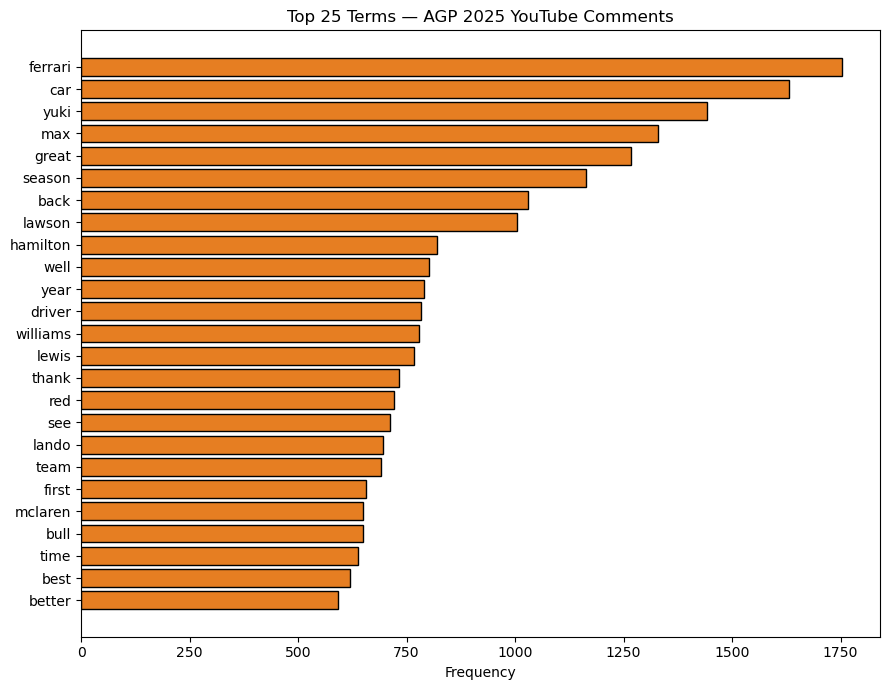

Sorting comment tokens into sentiment buckets...

Generating 4 sentiment word clouds...


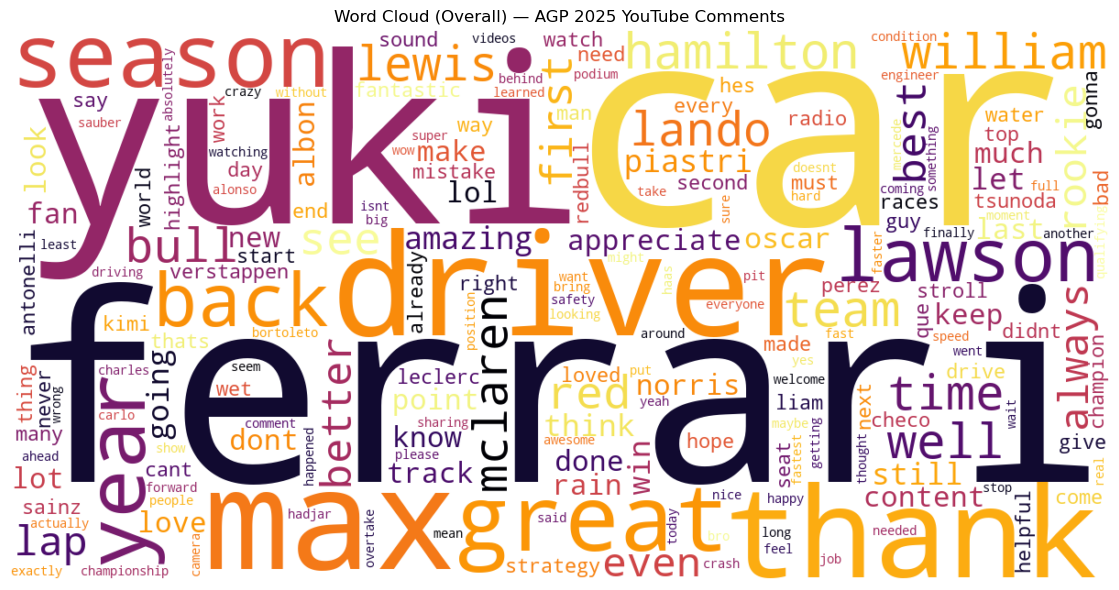

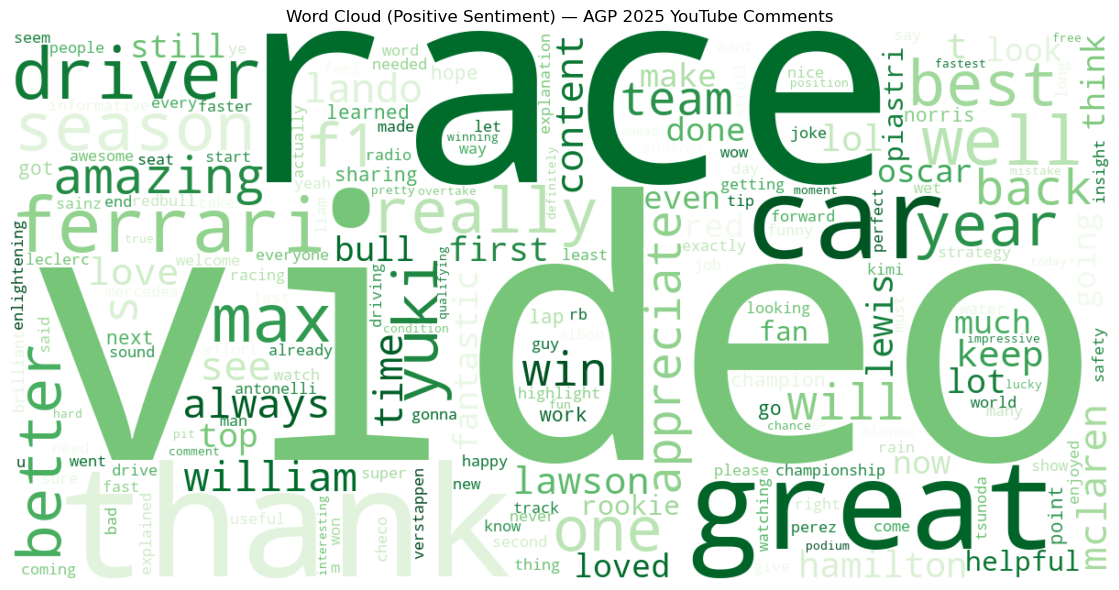

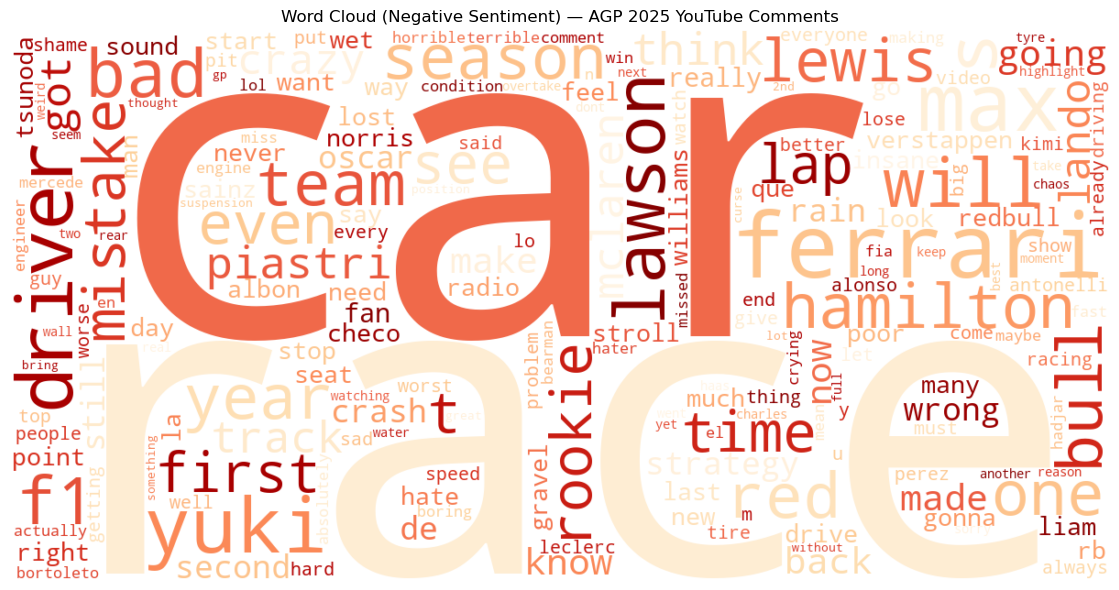

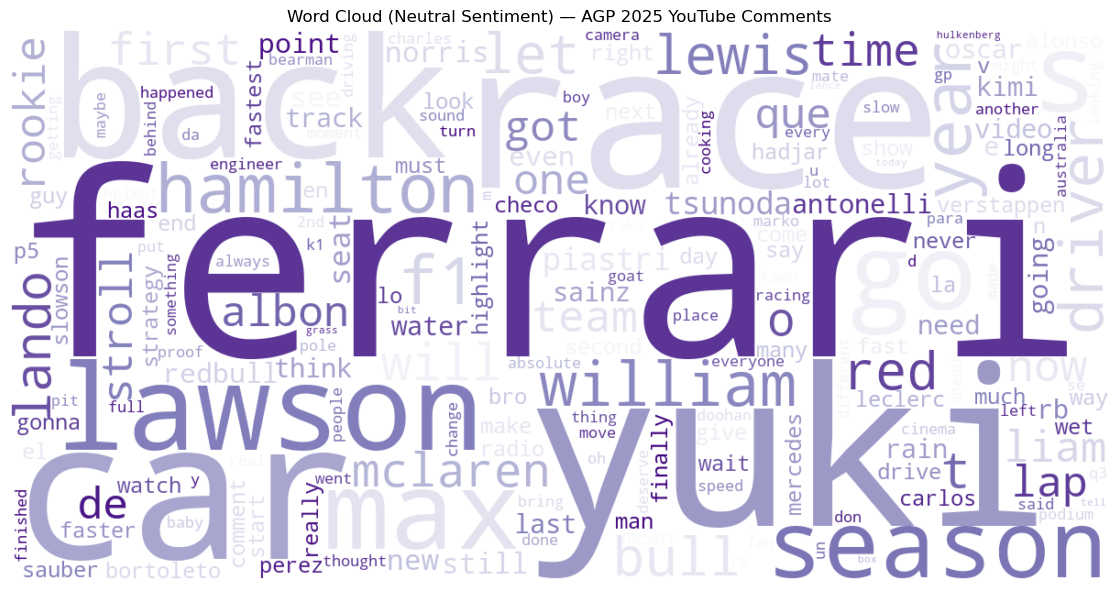

In [14]:
# --- 1. Top Terms Bar Chart (Kept Exactly As Original) ───────────────────────

plot_terms = word_freq.head(25).iloc[::-1]
plt.figure(figsize=(9, 7))
plt.barh(plot_terms['term'], plot_terms['frequency'], color='#E67E22', edgecolor='black')
plt.title('Top 25 Terms — AGP 2025 YouTube Comments')
plt.xlabel('Frequency')
plt.tight_layout()
plt.savefig(FIG_DIR / 'top_terms.png', dpi=160, bbox_inches='tight')
plt.show()


# --- 2. Extract Token Subsets for the 4 Sentiment Clouds ────────────────────

print("Sorting comment tokens into sentiment buckets...")

positive_tokens = []
negative_tokens = []
neutral_tokens = []

# Loop through rows to group tokens dynamically by their VADER sentiment tag
for _, row in df_comments.iterrows():
    comment_text = str(row.get('clean_comment', '')).strip()
    if not comment_text or comment_text.lower() == 'nan':
        continue
        
    tokens = comment_text.split()
    sentiment = row.get('sentiment', 'neutral')
    
    if sentiment == 'positive':
        positive_tokens.extend(tokens)
    elif sentiment == 'negative':
        negative_tokens.extend(tokens)
    else:
        neutral_tokens.extend(tokens)


# --- 3. Generate the 4 Word Clouds ──────────────────────────────────────────

# Blueprint map for processing the 4 target word clouds
clouds_config = [
    {
        "title": "Overall", 
        "tokens": all_tokens, 
        "filename": "wordcloud_overall.png", 
        "colormap": "inferno"
    },
    {
        "title": "Positive Sentiment", 
        "tokens": positive_tokens, 
        "filename": "wordcloud_positive.png", 
        "colormap": "Greens" # Positive green palette
    },
    {
        "title": "Negative Sentiment", 
        "tokens": negative_tokens, 
        "filename": "wordcloud_negative.png", 
        "colormap": "OrRd" # Striking oranges and reds
    },
    {
        "title": "Neutral Sentiment", 
        "tokens": neutral_tokens, 
        "filename": "wordcloud_neutral.png", 
        "colormap": "Purples" # Balanced purples
    }
]

if WORDCLOUD_AVAILABLE:
    print("\nGenerating 4 sentiment word clouds...")
    for cloud in clouds_config:
        # Verify that this specific category actually contains words to display
        if cloud["tokens"]:
            text_for_cloud = ' '.join(cloud["tokens"])
            
            # Generate the cloud configuration canvas
            wc = WordCloud(
                width=1200, 
                height=600, 
                background_color='white', 
                collocations=False, 
                colormap=cloud["colormap"]
            ).generate(text_for_cloud)
            
            # Create plot layout
            plt.figure(figsize=(12, 6))
            plt.imshow(wc, interpolation='bilinear')
            plt.axis('off')
            plt.title(f'Word Cloud ({cloud["title"]}) — AGP 2025 YouTube Comments')
            plt.tight_layout()
            
            # Save and clean render
            plt.savefig(FIG_DIR / cloud["filename"], dpi=160, bbox_inches='tight')
            plt.show()
        else:
            print(f"Skipped '{cloud['title']}' cloud: No tokens found for this sentiment category.")
else:
    print('WordCloud not available or no tokens found.')

## Section 6 — Topic Modelling with LDA

LDA is used to group comments into themes. This supports the report discussion by showing whether communities are discussing race incidents, drivers, teams, strategy, Melbourne/Albert Park, or media coverage.

Topic 0: best, ferrari, team, lewis, hamilton, back, radio, better, time, lol, watch, highlights
Topic 1: ferrari, thanks, always, amazing, lot, helpful, que, learned, sharing, appreciate, super, videos
Topic 2: great, thank, season, keep, well, first, next, loved, kimi, work, rookies, water
Topic 3: max, lando, car, piastri, mclaren, norris, oscar, win, stroll, track, rain, ferrari
Topic 4: yuki, lawson, car, williams, red, back, bull, driver, max, well, albon, redbull


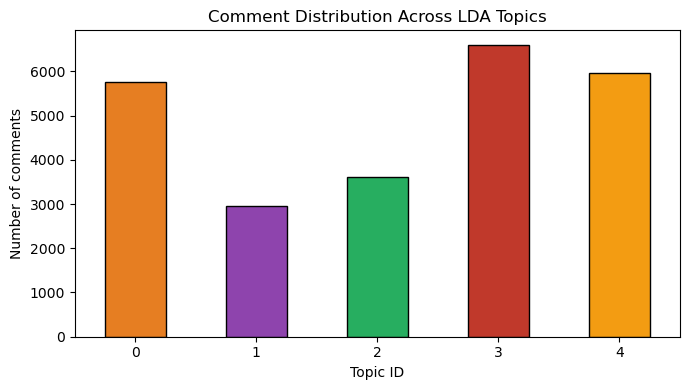

,topic_id,top_words
0,0,"best, ferrari, team, lewis, hamilton, back, ra..."
1,1,"ferrari, thanks, always, amazing, lot, helpful..."
2,2,"great, thank, season, keep, well, first, next,..."
3,3,"max, lando, car, piastri, mclaren, norris, osc..."
4,4,"yuki, lawson, car, williams, red, back, bull, ..."


In [15]:
N_TOPICS = 5
N_TOP_WORDS = 12

texts_for_lda = df_comments['tokens'].apply(lambda toks: ' '.join(toks))
texts_for_lda = texts_for_lda[texts_for_lda.str.len() > 0]

if len(texts_for_lda) < 20:
    print('Not enough comments for reliable LDA. Need at least ~20 non-empty comments.')
    topic_table = pd.DataFrame()
else:
    vectorizer = CountVectorizer(max_df=0.90, min_df=2, max_features=3000)
    dtm = vectorizer.fit_transform(texts_for_lda)
    lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=42, learning_method='batch')
    topic_matrix = lda.fit_transform(dtm)
    feature_names = np.array(vectorizer.get_feature_names_out())

    rows = []
    for topic_idx, topic in enumerate(lda.components_):
        top_indices = topic.argsort()[-N_TOP_WORDS:][::-1]
        top_words = feature_names[top_indices]
        rows.append({'topic_id': topic_idx, 'top_words': ', '.join(top_words)})
        print(f'Topic {topic_idx}: {", ".join(top_words)}')

    topic_table = pd.DataFrame(rows)
    topic_table.to_csv(TABLE_DIR / 'lda_topics.csv', index=False)

    # Assign topics back to comments with non-empty token strings.
    valid_idx = texts_for_lda.index
    df_comments['topic'] = np.nan
    df_comments.loc[valid_idx, 'topic'] = topic_matrix.argmax(axis=1)
    df_comments['topic'] = df_comments['topic'].fillna(-1).astype(int)

    topic_counts = df_comments[df_comments['topic'] >= 0]['topic'].value_counts().sort_index()
    plt.figure(figsize=(7, 4))
    topic_palette = ['#E67E22', '#8E44AD', '#27AE60', '#C0392B', '#F39C12', '#D81B60']
    topic_counts.plot(kind='bar', edgecolor='black', color=[topic_palette[i % len(topic_palette)] for i in range(len(topic_counts))])
    plt.title('Comment Distribution Across LDA Topics')
    plt.xlabel('Topic ID')
    plt.ylabel('Number of comments')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'lda_topic_distribution.png', dpi=160, bbox_inches='tight')
    plt.show()

df_comments.to_csv(DATA_DIR / 'agp2025_comments_with_sentiment_topics.csv', index=False, encoding='utf-8')
topic_table

## Section 6B — Topic Visualisation Figure (pyLDAvis-style)

This optional section generates an **intertopic distance map** similar to the LDA figures often shown in reports. It uses the fitted LDA model from the previous section and displays an interactive visualisation directly in the notebook when `pyLDAvis` is available.

If `pyLDAvis` is not installed, the notebook will skip this section without breaking. You can install it with the commented `%pip install` line in the setup cell.


In [16]:
# Optional intertopic distance visualisation (similar to the LDA screenshot style)
HTML_DIR = OUT_DIR / 'html'
HTML_DIR.mkdir(parents=True, exist_ok=True)

try:
    import pyLDAvis
    import pyLDAvis.sklearn
    from IPython.display import HTML, display
    PYLDAVIS_AVAILABLE = True
except Exception:
    PYLDAVIS_AVAILABLE = False

if PYLDAVIS_AVAILABLE and 'lda' in globals() and 'vectorizer' in globals() and 'dtm' in globals() and dtm.shape[0] > 0:
    try:
        lda_vis = pyLDAvis.sklearn.prepare(lda, dtm, vectorizer, mds='mmds')
        pyLDAvis.save_html(lda_vis, HTML_DIR / 'lda_intertopic_distance_map.html')
        print(f'Saved interactive LDA visualisation to: {HTML_DIR / "lda_intertopic_distance_map.html"}')
        display(HTML(lda_vis._repr_html_()))
    except Exception as e:
        print(f'pyLDAvis generation warning: {e}')
else:
    print('pyLDAvis is unavailable or LDA objects were not created. Skipping interactive topic visualisation.')


pyLDAvis is unavailable or LDA objects were not created. Skipping interactive topic visualisation.


## Section 7 — Temporal Sentiment Analysis 

This section extends the VADER sentiment analysis by examining how
fan sentiment shifted across three key periods around the race weekend.

**Race weekend dates:** 14–16 March 2025 (Albert Park, Melbourne)

**Three periods:**
- **Pre-race**: comments posted before 14 March 2025
- **Race weekend**: comments posted 14–16 March 2025  
- **Post-race**: comments posted after 16 March 2025

**Why this matters:**
Race incidents, penalties, and results typically trigger sentiment
shifts. If post-race sentiment is more negative than pre-race,
it suggests controversial events drove negative discourse.
This directly supports the research question about sentiment-based
community formation around controversial events.

In [17]:
def build_reply_network(df):
    """Directed network: replying user -> parent comment user."""
    G = nx.DiGraph()

    users = df['user_alias'].dropna().unique()
    G.add_nodes_from(users)

    if 'is_reply' not in df.columns:
        return G

    replies = df[(df['is_reply'] == True) & df['parent_user_alias'].notna()].copy()
    for _, row in replies.iterrows():
        u = row['user_alias']
        v = row['parent_user_alias']
        if not u or not v or u == v:
            continue
        if G.has_edge(u, v):
            G[u][v]['weight'] += 1
            G[u][v]['comments'] += 1
        else:
            G.add_edge(u, v, weight=1, comments=1, relation='reply')

    return G


def build_user_video_bipartite(df):
    """Bipartite graph: users connected to videos they commented on."""
    B = nx.Graph()
    for _, row in df.iterrows():
        user = row['user_alias']
        vid = 'Video_' + str(row['videoId'])
        B.add_node(user, bipartite='user')
        B.add_node(vid, bipartite='video', title=row.get('video_title', ''))
        if B.has_edge(user, vid):
            B[user][vid]['weight'] += 1
        else:
            B.add_edge(user, vid, weight=1)
    return B


def build_co_comment_network(df, max_users_per_video=600):
    """
    Undirected network: users connected if they comment on the same video.
    To avoid huge complete graphs for very large videos, each video can be capped to the most active users.
    """
    G = nx.Graph()
    G.add_nodes_from(df['user_alias'].dropna().unique())

    for vid, group in df.groupby('videoId'):
        counts = group['user_alias'].value_counts()
        users = list(counts.index[:max_users_per_video])
        for u, v in combinations(users, 2):
            w = int(counts[u] + counts[v])
            if G.has_edge(u, v):
                G[u][v]['weight'] += 1
                G[u][v]['shared_videos'] += 1
            else:
                G.add_edge(u, v, weight=1, shared_videos=1, relation='co_comment')
    return G


G_reply = build_reply_network(df_comments)
B_user_video = build_user_video_bipartite(df_comments)
G_cocomment = build_co_comment_network(df_comments, max_users_per_video=600)

# Main graph choice: use reply network when enough reply edges exist, otherwise use co-comment network.
MIN_REPLY_EDGES_FOR_MAIN = 20
if G_reply.number_of_edges() >= MIN_REPLY_EDGES_FOR_MAIN:
    G_main = G_reply.copy()
    MAIN_GRAPH_TYPE = 'directed_reply'
else:
    G_main = G_cocomment.copy()
    MAIN_GRAPH_TYPE = 'undirected_co_comment'

print('Network summary')
print(f'  Reply network      : {G_reply.number_of_nodes()} nodes, {G_reply.number_of_edges()} edges')
print(f'  Co-comment network : {G_cocomment.number_of_nodes()} nodes, {G_cocomment.number_of_edges()} edges')
print(f'  Bipartite network  : {B_user_video.number_of_nodes()} nodes, {B_user_video.number_of_edges()} edges')
print(f'  Main analysis graph: {MAIN_GRAPH_TYPE}')

nx.write_graphml(G_reply, GRAPH_DIR / 'reply_network.graphml')
nx.write_graphml(G_cocomment, GRAPH_DIR / 'co_comment_network.graphml')
nx.write_graphml(B_user_video, GRAPH_DIR / 'user_video_bipartite.graphml')
print('GraphML files exported to outputs/graphs/')

Network summary
  Reply network      : 19161 nodes, 5990 edges
  Co-comment network : 19161 nodes, 1297284 edges
  Bipartite network  : 19181 nodes, 21010 edges
  Main analysis graph: directed_reply
GraphML files exported to outputs/graphs/


In [18]:
# Add node attributes: sentiment, comment counts, likes, dominant topic.
user_stats = df_comments.groupby('user_alias').agg(
    comments=('comment_id', 'count'),
    avg_sentiment=('compound_score', 'mean'),
    total_likes=('likeCount', 'sum'),
    positive_share=('sentiment', lambda s: (s == 'positive').mean()),
    negative_share=('sentiment', lambda s: (s == 'negative').mean()),
    videos_commented=('videoId', 'nunique')
).reset_index()

if 'topic' in df_comments.columns:
    dominant_topic = df_comments.groupby('user_alias')['topic'].agg(lambda s: s.value_counts().index[0]).to_dict()
else:
    dominant_topic = {}

user_stats_map = user_stats.set_index('user_alias').to_dict(orient='index')

for G in [G_reply, G_cocomment, G_main]:
    for node in G.nodes():
        stats = user_stats_map.get(node, {})
        for key, value in stats.items():
            G.nodes[node][key] = float(value) if isinstance(value, (np.floating, float)) else int(value) if isinstance(value, (np.integer, int)) else value
        G.nodes[node]['dominant_topic'] = int(dominant_topic.get(node, -1))

nx.write_graphml(G_main, GRAPH_DIR / 'main_analysis_network_with_attributes.graphml')
user_stats.to_csv(TABLE_DIR / 'user_level_comment_stats.csv', index=False)
user_stats.head()

,user_alias,comments,avg_sentiment,total_likes,positive_share,negative_share,videos_commented
0,User_000001,1,0.4549,1,1.0,0.0,1
1,User_000002,1,-0.5423,0,0.0,1.0,1
2,User_000003,1,0.0000,1,0.0,0.0,1
3,User_000004,1,-0.2023,0,0.0,1.0,1
4,User_000005,1,-0.5994,0,0.0,1.0,1


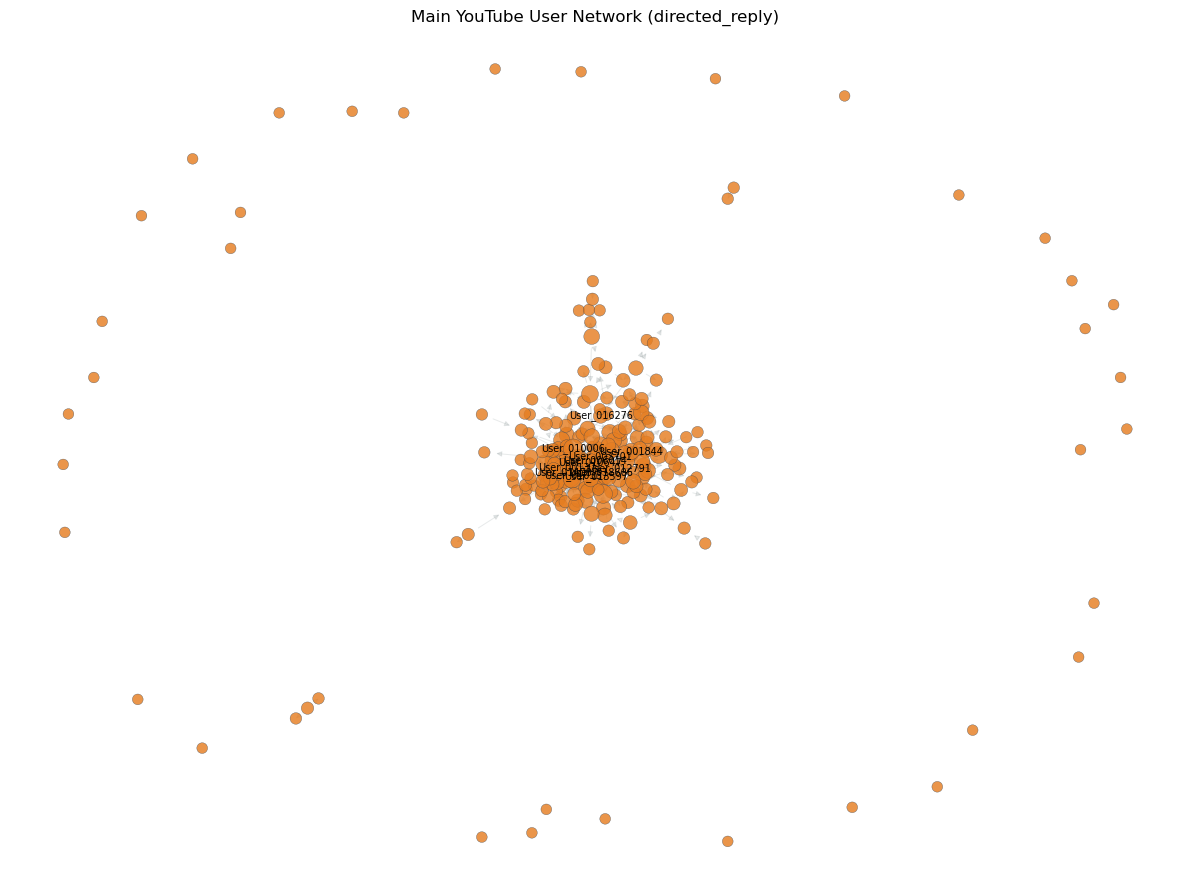

In [19]:
def plot_network_sample(G, title, out_file, max_nodes=250):
    """Plot a readable sample/subgraph of the network."""
    if G.number_of_nodes() == 0:
        print(f'{title}: graph is empty.')
        return

    # Use largest component for undirected view. Directed graphs are converted to undirected for layout.
    H_layout = G.to_undirected() if G.is_directed() else G.copy()
    if H_layout.number_of_edges() == 0:
        print(f'{title}: graph has no edges.')
        return

    largest_nodes = max(nx.connected_components(H_layout), key=len)
    H = G.subgraph(largest_nodes).copy()

    if H.number_of_nodes() > max_nodes:
        degrees = dict(H.degree(weight='weight'))
        keep = sorted(degrees, key=degrees.get, reverse=True)[:max_nodes]
        H = H.subgraph(keep).copy()

    H_und = H.to_undirected() if H.is_directed() else H
    pos = nx.spring_layout(H_und, seed=42, k=1/math.sqrt(max(H.number_of_nodes(), 1)))
    node_sizes = [60 + 10 * H.degree(n) for n in H.nodes()]

    plt.figure(figsize=(12, 9))
    nx.draw_networkx_edges(H, pos, alpha=0.18, arrows=G.is_directed(), arrowsize=8, width=0.7, edge_color='#7F8C8D')
    nx.draw_networkx_nodes(H, pos, node_size=node_sizes, alpha=0.82, node_color='#E67E22', edgecolors='#2C3E50', linewidths=0.25)

    top_labels = sorted(dict(H.degree(weight='weight')).items(), key=lambda x: x[1], reverse=True)[:12]
    nx.draw_networkx_labels(H, pos, labels={n:n for n, _ in top_labels}, font_size=7)

    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(out_file, dpi=160, bbox_inches='tight')
    plt.show()

plot_network_sample(G_main, f'Main YouTube User Network ({MAIN_GRAPH_TYPE})', FIG_DIR / 'main_user_network.png')

## Section 8 — Social Network Analysis Measures

This section uses lab-style NetworkX centrality measures to identify influential users.

- **Degree / in-degree / out-degree:** direct interaction reach.
- **PageRank:** useful for directed reply influence because replies point toward users receiving attention.
- **Betweenness centrality:** identifies bridge users between groups.
- **Eigenvector centrality:** identifies users connected to other central users.
- **Clustering:** shows local community cohesion.

In [20]:
def compute_centrality_table(G):
    if G.number_of_nodes() == 0:
        return pd.DataFrame()

    if G.is_directed():
        degree_c = nx.degree_centrality(G)
        indegree_c = nx.in_degree_centrality(G)
        outdegree_c = nx.out_degree_centrality(G)
        pagerank = nx.pagerank(G, weight='weight') if G.number_of_edges() > 0 else {n: 0 for n in G.nodes()}
        H = G.to_undirected()
    else:
        degree_c = nx.degree_centrality(G)
        indegree_c = degree_c
        outdegree_c = degree_c
        pagerank = nx.pagerank(G, weight='weight') if G.number_of_edges() > 0 else {n: 0 for n in G.nodes()}
        H = G

    # Approximate betweenness for large graphs.
    if H.number_of_nodes() > 800:
        k = min(300, H.number_of_nodes())
        betweenness = nx.betweenness_centrality(H, k=k, seed=42, weight='weight')
    else:
        betweenness = nx.betweenness_centrality(H, weight='weight')

    try:
        eigenvector = nx.eigenvector_centrality(H, max_iter=1000, weight='weight')
    except Exception:
        eigenvector = degree_c

    clustering = nx.clustering(H, weight='weight') if H.number_of_edges() > 0 else {n:0 for n in H.nodes()}

    rows = []
    for n in G.nodes():
        stats = user_stats_map.get(n, {})
        rows.append({
            'user_alias': n,
            'degree_c': degree_c.get(n, 0),
            'in_degree_c': indegree_c.get(n, 0),
            'out_degree_c': outdegree_c.get(n, 0),
            'pagerank': pagerank.get(n, 0),
            'betweenness_c': betweenness.get(n, 0),
            'eigenvector_c': eigenvector.get(n, 0),
            'clustering': clustering.get(n, 0),
            'comments': stats.get('comments', 0),
            'avg_sentiment': stats.get('avg_sentiment', np.nan),
            'total_likes': stats.get('total_likes', 0),
            'videos_commented': stats.get('videos_commented', 0),
        })

    cent = pd.DataFrame(rows)
    score_cols = ['degree_c', 'pagerank', 'betweenness_c', 'eigenvector_c']
    for col in score_cols:
        rng = cent[col].max() - cent[col].min()
        cent[col + '_norm'] = (cent[col] - cent[col].min()) / (rng + 1e-12)
    cent['influence_score'] = cent[[c + '_norm' for c in score_cols]].mean(axis=1)
    return cent.sort_values('influence_score', ascending=False)

cent_df = compute_centrality_table(G_main)
cent_df.to_csv(TABLE_DIR / 'centrality_influence_table.csv', index=False)
cent_df.head(20)

,user_alias,degree_c,in_degree_c,out_degree_c,pagerank,betweenness_c,eigenvector_c,clustering,comments,avg_sentiment,total_likes,videos_commented,degree_c_norm,pagerank_norm,betweenness_c_norm,eigenvector_c_norm,influence_score
13637,User_010006,0.027140,0.027140,0.000000,0.017807,0.021799,0.655413,0.000007,1,0.000000,17997,1,1.000000,1.000000,1.000000,1.000000,1.000000
12246,User_010647,0.013674,0.013674,0.000000,0.008605,0.008286,0.111832,0.000000,1,0.526700,27192,1,0.503846,0.481959,0.380102,0.170629,0.384134
7622,User_006014,0.012787,0.012787,0.000000,0.007915,0.009191,0.067247,0.000018,2,0.484700,43541,2,0.471154,0.443157,0.421639,0.102603,0.359638
0,User_003701,0.006054,0.006054,0.000000,0.004109,0.002780,0.191770,0.000075,2,-0.458800,36426,1,0.223077,0.228873,0.127551,0.292594,0.218024
6195,User_009741,0.004906,0.004906,0.000000,0.002642,0.006859,0.012076,0.000000,1,0.381800,15262,1,0.180769,0.146276,0.314648,0.018424,0.165029
105,User_010337,0.002349,0.000000,0.002349,0.000043,0.010428,0.058219,0.000239,60,0.147752,34,3,0.086538,0.000000,0.478382,0.088828,0.163437
7541,User_013597,0.006054,0.006002,0.000052,0.003339,0.003470,0.056000,0.000000,2,-0.156000,25633,2,0.223077,0.185559,0.159201,0.085442,0.163320
16938,User_004327,0.005689,0.005689,0.000000,0.003826,0.002993,0.023181,0.000025,1,0.000000,16464,1,0.209615,0.212963,0.137301,0.035368,0.148812
6854,User_012791,0.004749,0.004749,0.000000,0.002424,0.005302,0.019058,0.000000,1,0.569700,12057,1,0.175000,0.134023,0.243228,0.029078,0.145332
12489,User_013014,0.004854,0.004854,0.000000,0.002736,0.003442,0.032168,0.000000,2,0.142450,12668,2,0.178846,0.151611,0.157908,0.049081,0.134361


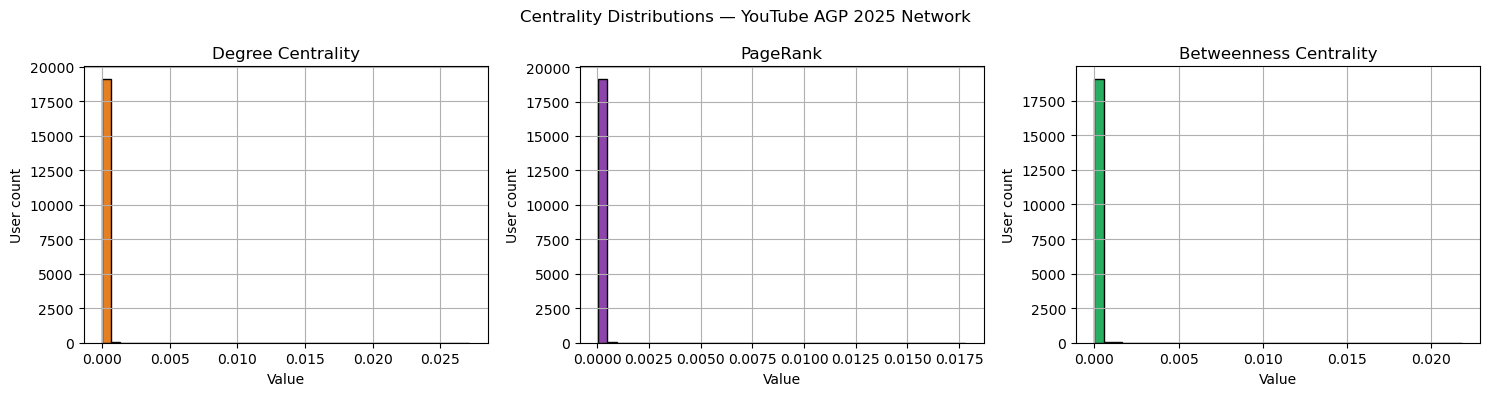

Top 20 influential pseudonymous users


,user_alias,influence_score,degree_c,pagerank,betweenness_c,avg_sentiment,comments,videos_commented
13637,User_010006,1.000000,0.027140,0.017807,0.021799,0.000000,1,1
12246,User_010647,0.384134,0.013674,0.008605,0.008286,0.526700,1,1
7622,User_006014,0.359638,0.012787,0.007915,0.009191,0.484700,2,2
0,User_003701,0.218024,0.006054,0.004109,0.002780,-0.458800,2,1
6195,User_009741,0.165029,0.004906,0.002642,0.006859,0.381800,1,1
105,User_010337,0.163437,0.002349,0.000043,0.010428,0.147752,60,3
7541,User_013597,0.163320,0.006054,0.003339,0.003470,-0.156000,2,2
16938,User_004327,0.148812,0.005689,0.003826,0.002993,0.000000,1,1
6854,User_012791,0.145332,0.004749,0.002424,0.005302,0.569700,1,1
12489,User_013014,0.134361,0.004854,0.002736,0.003442,0.142450,2,2


In [21]:
# Plot centrality distributions
if not cent_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    cent_df['degree_c'].hist(ax=axes[0], bins=40, edgecolor='black', color='#E67E22')
    axes[0].set_title('Degree Centrality')
    axes[0].set_xlabel('Value')
    cent_df['pagerank'].hist(ax=axes[1], bins=40, edgecolor='black', color='#8E44AD')
    axes[1].set_title('PageRank')
    axes[1].set_xlabel('Value')
    cent_df['betweenness_c'].hist(ax=axes[2], bins=40, edgecolor='black', color='#27AE60')
    axes[2].set_title('Betweenness Centrality')
    axes[2].set_xlabel('Value')
    for ax in axes:
        ax.set_ylabel('User count')
    plt.suptitle('Centrality Distributions — YouTube AGP 2025 Network')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'centrality_distributions.png', dpi=160, bbox_inches='tight')
    plt.show()

    display_cols = ['user_alias', 'influence_score', 'degree_c', 'pagerank', 'betweenness_c', 'avg_sentiment', 'comments', 'videos_commented']
    print('Top 20 influential pseudonymous users')
    display(cent_df[display_cols].head(20))
else:
    print('Centrality table is empty.')

In [22]:
# Structural network measures
H_main = G_main.to_undirected() if G_main.is_directed() else G_main.copy()

structural_summary = {
    'main_graph_type': MAIN_GRAPH_TYPE,
    'nodes': G_main.number_of_nodes(),
    'edges': G_main.number_of_edges(),
    'density': nx.density(G_main) if G_main.number_of_nodes() > 1 else 0,
    'is_directed': G_main.is_directed(),
    'components_undirected': nx.number_connected_components(H_main) if H_main.number_of_nodes() > 0 else 0,
    'avg_clustering_undirected': nx.average_clustering(H_main, weight='weight') if H_main.number_of_edges() > 0 else 0,
    'transitivity_undirected': nx.transitivity(H_main) if H_main.number_of_edges() > 0 else 0,
}

if H_main.number_of_nodes() > 0:
    comp_sizes = sorted([len(c) for c in nx.connected_components(H_main)], reverse=True)
    structural_summary['largest_component_size'] = comp_sizes[0]
    structural_summary['largest_component_share'] = comp_sizes[0] / H_main.number_of_nodes()
else:
    structural_summary['largest_component_size'] = 0
    structural_summary['largest_component_share'] = 0

structural_df = pd.DataFrame([structural_summary])
structural_df.to_csv(TABLE_DIR / 'network_structural_summary.csv', index=False)
structural_df.T

,0
main_graph_type,directed_reply
nodes,19161
edges,5990
density,0.000016
is_directed,True
components_undirected,14096
avg_clustering_undirected,0.000035
transitivity_undirected,0.000301
largest_component_size,4565
largest_component_share,0.238244


## Section 9 — Community Detection

Communities are detected using Louvain if available, otherwise greedy modularity from NetworkX. These communities help interpret fan groups as clusters of users who interact or participate in the same discussion spaces.

Community method: Greedy Modularity
Number of communities: 14139


,community,size,avg_sentiment,avg_influence
0,0,490,0.100634,0.011312
1,1,427,0.146964,0.003552
2,2,282,0.122142,0.003891
3,3,282,0.047709,0.003519
4,4,258,0.099725,0.004094
5,5,238,0.110110,0.003252
6,6,211,0.120047,0.005987
7,7,189,0.042173,0.003490
8,8,158,0.106314,0.002190
9,9,154,0.107911,0.002773


<Figure size 900x400 with 0 Axes>

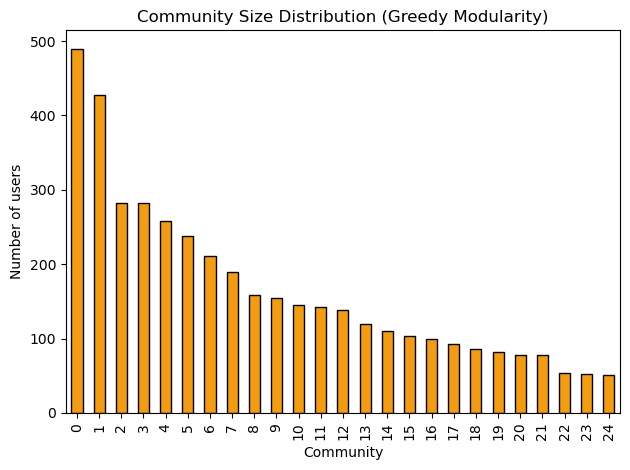

In [23]:
def detect_communities(G):
    if G.number_of_nodes() == 0:
        return {}, 'none'
    H = G.to_undirected() if G.is_directed() else G.copy()
    if H.number_of_edges() == 0:
        return {n: i for i, n in enumerate(H.nodes())}, 'isolates'

    try:
        import community as community_louvain
        partition = community_louvain.best_partition(H, weight='weight', random_state=42)
        method = 'Louvain'
    except Exception:
        from networkx.algorithms.community import greedy_modularity_communities
        comms = greedy_modularity_communities(H, weight='weight')
        partition = {}
        for cid, comm in enumerate(comms):
            for n in comm:
                partition[n] = cid
        method = 'Greedy Modularity'
    return partition, method

partition, community_method = detect_communities(G_main)

for node, cid in partition.items():
    G_main.nodes[node]['community'] = int(cid)

community_sizes = pd.Series(partition).value_counts().rename_axis('community').reset_index(name='size')
community_sizes.to_csv(TABLE_DIR / 'community_sizes.csv', index=False)

community_user_sent = cent_df.copy()
community_user_sent['community'] = community_user_sent['user_alias'].map(partition)
community_summary = (
    community_user_sent.groupby('community')
    .agg(size=('user_alias','count'), avg_sentiment=('avg_sentiment','mean'), avg_influence=('influence_score','mean'))
    .reset_index()
    .sort_values('size', ascending=False)
)
community_summary.to_csv(TABLE_DIR / 'community_summary.csv', index=False)

print(f'Community method: {community_method}')
print(f'Number of communities: {community_sizes.shape[0]}')
display(community_summary.head(15))

plt.figure(figsize=(9, 4))
community_sizes.head(25).plot(x='community', y='size', kind='bar', legend=False, edgecolor='black', color='#F39C12')
plt.title(f'Community Size Distribution ({community_method})')
plt.xlabel('Community')
plt.ylabel('Number of users')
plt.tight_layout()
plt.savefig(FIG_DIR / 'community_size_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

## Section 9B — Figure Gallery: Network Visualisations Similar to the Example PDF

The next cells generate **the same kinds of figure types** as the example PDF, but using your **AGP 2025 YouTube data** rather than the Trump/ASX project.

These figure types include:

1. **Dense overview / hairball network figure**
2. **First-degree ego network** of the most central commenter
3. **Second-degree local network** around the same focal commenter
4. **Community-coloured network figure**
5. **Top community detail figures**
6. **Community detail with node size proportional to centrality**
7. **Centrality-highlighted local network views**

The code below is generic to your project and does not include any Trump-specific logic.


In [24]:
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap

COMMUNITY_PALETTE = ['#E67E22', '#8E44AD', '#27AE60', '#C0392B', '#F39C12', '#D81B60', '#795548', '#7F8C8D', '#F1C40F', '#6C3483', '#A04000', '#196F3D']
COMMUNITY_CMAP = ListedColormap(COMMUNITY_PALETTE)


def _largest_component_graph(G):
    H = G.to_undirected() if G.is_directed() else G.copy()
    if H.number_of_nodes() == 0:
        return G.copy()
    if H.number_of_edges() == 0:
        return G.copy()
    largest_nodes = max(nx.connected_components(H), key=len)
    return G.subgraph(largest_nodes).copy()


def _trim_graph_by_degree(G, max_nodes=1000):
    if G.number_of_nodes() <= max_nodes:
        return G.copy()
    deg = dict(G.degree(weight='weight'))
    keep = sorted(deg, key=deg.get, reverse=True)[:max_nodes]
    return G.subgraph(keep).copy()


def _make_layout(H):
    H_und = H.to_undirected() if H.is_directed() else H.copy()
    n = max(H_und.number_of_nodes(), 1)
    if n <= 120:
        try:
            return nx.kamada_kawai_layout(H_und)
        except Exception:
            pass
    return nx.spring_layout(H_und, seed=42, k=1 / math.sqrt(n), iterations=150)


def _top_label_nodes(score_dict, top_n=15):
    if not score_dict:
        return []
    return [n for n, _ in sorted(score_dict.items(), key=lambda x: x[1], reverse=True)[:top_n]]


def plot_dense_overview(G, title, out_file, max_nodes=1400):
    H = _largest_component_graph(G)
    H = _trim_graph_by_degree(H, max_nodes=max_nodes)
    if H.number_of_nodes() == 0:
        print(f'{title}: graph is empty.')
        return None
    if H.number_of_edges() == 0:
        print(f'{title}: graph has no edges.')
        return H

    pos = _make_layout(H)
    deg = dict(H.degree(weight='weight'))
    sizes = [max(4, 8 + 3 * math.sqrt(deg.get(n, 1))) for n in H.nodes()]

    plt.figure(figsize=(12, 10))
    nx.draw_networkx_edges(H, pos, alpha=0.05, width=0.28, arrows=False, edge_color='#7F8C8D')
    nx.draw_networkx_nodes(H, pos, node_size=sizes, alpha=0.45, node_color='#E67E22', edgecolors='#2C3E50', linewidths=0.15)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(out_file, dpi=180, bbox_inches='tight')
    plt.show()
    return H


def plot_ego_figure(G, focal_node, title, out_file, radius=1, top_label_count=25):
    if focal_node not in G:
        print(f'{title}: focal node not found in graph.')
        return None
    H_base = G.to_undirected() if G.is_directed() else G
    ego = nx.ego_graph(H_base, focal_node, radius=radius)
    H = G.subgraph(ego.nodes()).copy()
    if H.number_of_nodes() == 0:
        print(f'{title}: empty ego graph.')
        return None

    pos = _make_layout(H)
    deg = dict(H.degree(weight='weight'))

    node_colors = []
    node_sizes = []
    for n in H.nodes():
        if n == focal_node:
            node_colors.append('#C0392B')
            node_sizes.append(650)
        elif H_base.has_edge(focal_node, n):
            node_colors.append('#27AE60')
            node_sizes.append(160)
        else:
            node_colors.append('#8E44AD')
            node_sizes.append(60 + 6 * min(deg.get(n, 1), 15))

    plt.figure(figsize=(12, 9))
    nx.draw_networkx_edges(H, pos, alpha=0.22, width=0.60, arrows=G.is_directed(), arrowsize=8, edge_color='#7F8C8D')
    nx.draw_networkx_nodes(H, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85)

    label_nodes = {focal_node}
    label_nodes.update(_top_label_nodes(deg, top_n=top_label_count))
    nx.draw_networkx_labels(H, pos, labels={n: n for n in label_nodes if n in H.nodes()}, font_size=7)

    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(out_file, dpi=180, bbox_inches='tight')
    plt.show()
    return H


def plot_community_coloured_network(G, partition, title, out_file, max_nodes=1200):
    if not partition:
        print(f'{title}: no community partition available.')
        return None
    H = _largest_component_graph(G)
    if H.number_of_nodes() > max_nodes:
        deg = dict(H.degree(weight='weight'))
        # keep higher-degree nodes but preserve representation across larger communities
        size_df = pd.Series(partition).value_counts()
        keep = []
        for cid in size_df.index[:12]:
            community_nodes = [n for n in H.nodes() if partition.get(n) == cid]
            community_nodes = sorted(community_nodes, key=lambda n: deg.get(n, 0), reverse=True)[:max(20, max_nodes // 12)]
            keep.extend(community_nodes)
        if len(set(keep)) < max_nodes:
            extras = [n for n, _ in sorted(deg.items(), key=lambda x: x[1], reverse=True) if n not in keep]
            keep.extend(extras[:max_nodes - len(set(keep))])
        H = H.subgraph(list(dict.fromkeys(keep))[:max_nodes]).copy()

    pos = _make_layout(H)
    community_ids = sorted({partition.get(n, -1) for n in H.nodes()})
    cmap = COMMUNITY_CMAP
    cid_to_color = {cid: cmap(i % cmap.N) for i, cid in enumerate(community_ids)}
    node_colors = [cid_to_color.get(partition.get(n, -1), (0.6, 0.6, 0.6, 1.0)) for n in H.nodes()]
    influence_map = cent_df.set_index('user_alias')['influence_score'].to_dict() if 'cent_df' in globals() and not cent_df.empty else {}
    node_sizes = [18 + 280 * influence_map.get(n, 0.02) for n in H.nodes()]

    plt.figure(figsize=(13, 10))
    nx.draw_networkx_edges(H, pos, alpha=0.07, width=0.40, edge_color='#7F8C8D', arrows=False)
    nx.draw_networkx_nodes(H, pos, node_size=node_sizes, node_color=node_colors, alpha=0.80, linewidths=0.2)

    label_nodes = _top_label_nodes({n: influence_map.get(n, 0) for n in H.nodes()}, top_n=18)
    nx.draw_networkx_labels(H, pos, labels={n: n for n in label_nodes}, font_size=7)

    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(out_file, dpi=180, bbox_inches='tight')
    plt.show()
    return H


def plot_single_community(G, partition, community_id, title, out_file, max_nodes=350, centrality_metric='degree'):
    nodes = [n for n in G.nodes() if partition.get(n) == community_id]
    H = G.subgraph(nodes).copy()
    if H.number_of_nodes() == 0:
        print(f'{title}: community is empty.')
        return None
    H = _largest_component_graph(H)
    if H.number_of_nodes() > max_nodes:
        if 'cent_df' in globals() and not cent_df.empty and centrality_metric in cent_df.columns:
            score_map = cent_df.set_index('user_alias')[centrality_metric].to_dict()
        else:
            score_map = dict(H.degree(weight='weight'))
        keep = sorted(H.nodes(), key=lambda n: score_map.get(n, 0), reverse=True)[:max_nodes]
        H = H.subgraph(keep).copy()
    pos = _make_layout(H)

    if 'cent_df' in globals() and not cent_df.empty:
        if centrality_metric in cent_df.columns:
            score_map = cent_df.set_index('user_alias')[centrality_metric].to_dict()
        else:
            score_map = cent_df.set_index('user_alias')['influence_score'].to_dict()
    else:
        score_map = dict(H.degree(weight='weight'))

    scores = [score_map.get(n, 0) for n in H.nodes()]
    if len(scores) > 0:
        max_score = max(scores) if max(scores) > 0 else 1
        node_sizes = [40 + 900 * (score_map.get(n, 0) / max_score) for n in H.nodes()]
    else:
        node_sizes = [60 for _ in H.nodes()]

    plt.figure(figsize=(12, 9))
    nx.draw_networkx_edges(H, pos, alpha=0.12, width=0.50, edge_color='#7F8C8D', arrows=G.is_directed(), arrowsize=8)
    nx.draw_networkx_nodes(H, pos, node_size=node_sizes, alpha=0.85, node_color='#F39C12', edgecolors='#2C3E50', linewidths=0.25)

    label_nodes = _top_label_nodes(score_map, top_n=20)
    nx.draw_networkx_labels(H, pos, labels={n: n for n in label_nodes if n in H.nodes()}, font_size=7)

    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(out_file, dpi=180, bbox_inches='tight')
    plt.show()
    return H


def plot_centrality_highlight_network(G, nodes, score_map, title, out_file, edge_color='#7F8C8D'):
    H = G.subgraph(nodes).copy()
    if H.number_of_nodes() == 0:
        print(f'{title}: graph is empty.')
        return None
    pos = _make_layout(H)
    values = [score_map.get(n, 0) for n in H.nodes()]
    vmax = max(values) if values and max(values) > 0 else 1
    node_sizes = [40 + 1200 * (score_map.get(n, 0) / vmax) for n in H.nodes()]

    plt.figure(figsize=(12, 9))
    nx.draw_networkx_edges(H, pos, alpha=0.10, width=0.40, edge_color=edge_color, arrows=G.is_directed(), arrowsize=8)
    nx.draw_networkx_nodes(H, pos, node_size=node_sizes, alpha=0.85, node_color='#8E44AD', edgecolors='#2C3E50', linewidths=0.25)
    label_nodes = _top_label_nodes({n: score_map.get(n, 0) for n in H.nodes()}, top_n=18)
    nx.draw_networkx_labels(H, pos, labels={n: n for n in label_nodes}, font_size=7)
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(out_file, dpi=180, bbox_inches='tight')
    plt.show()
    return H


Focal commenter used for ego-network figures: User_010006


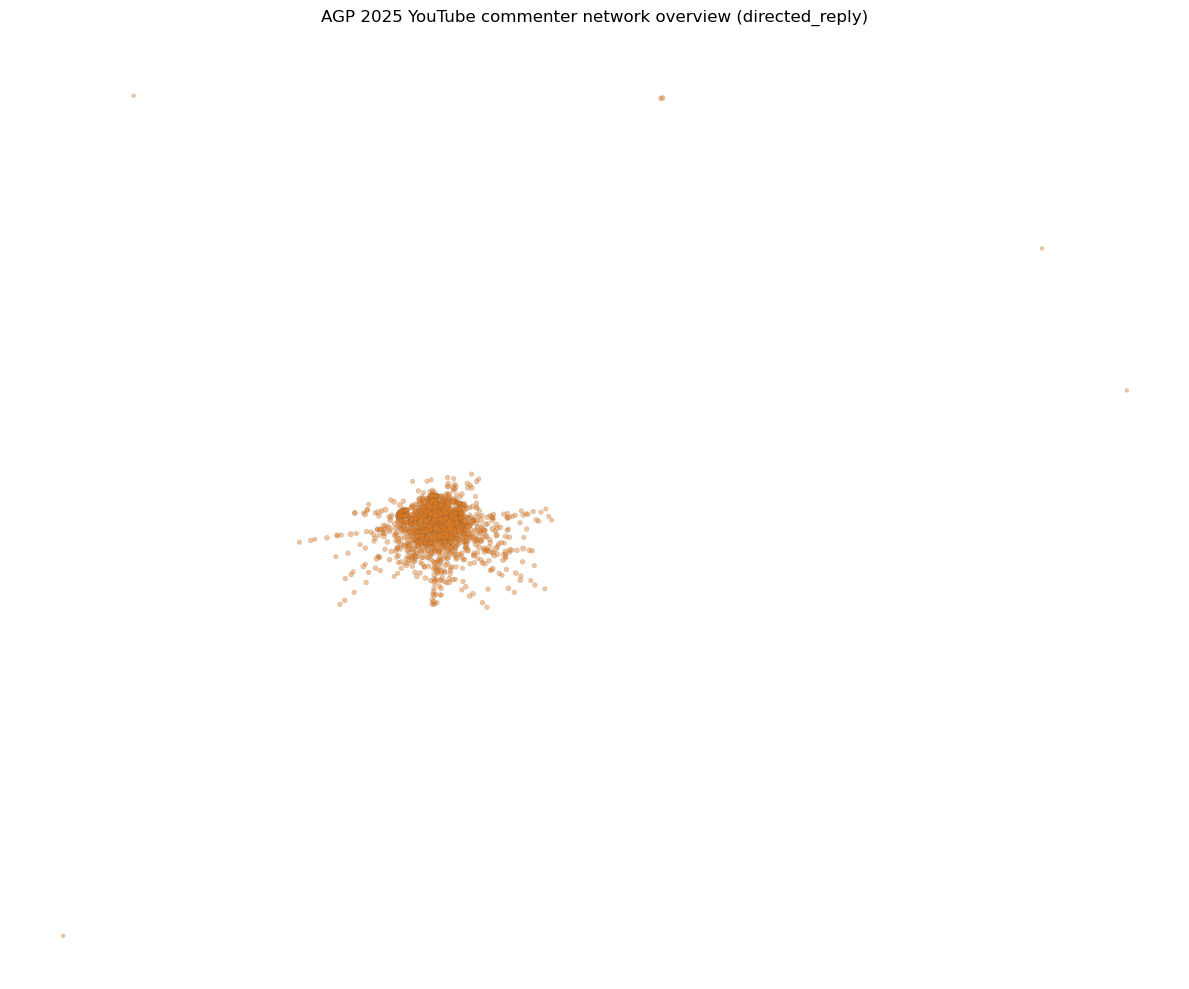

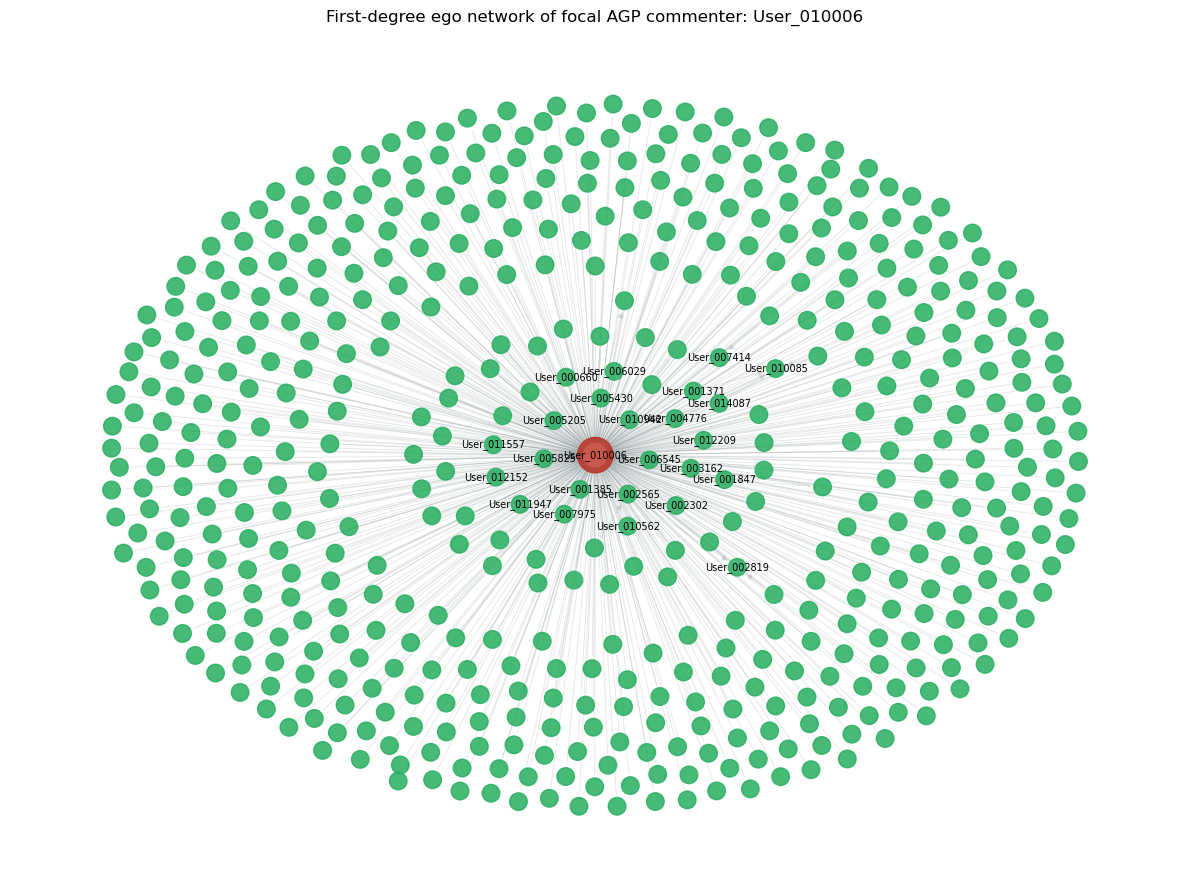

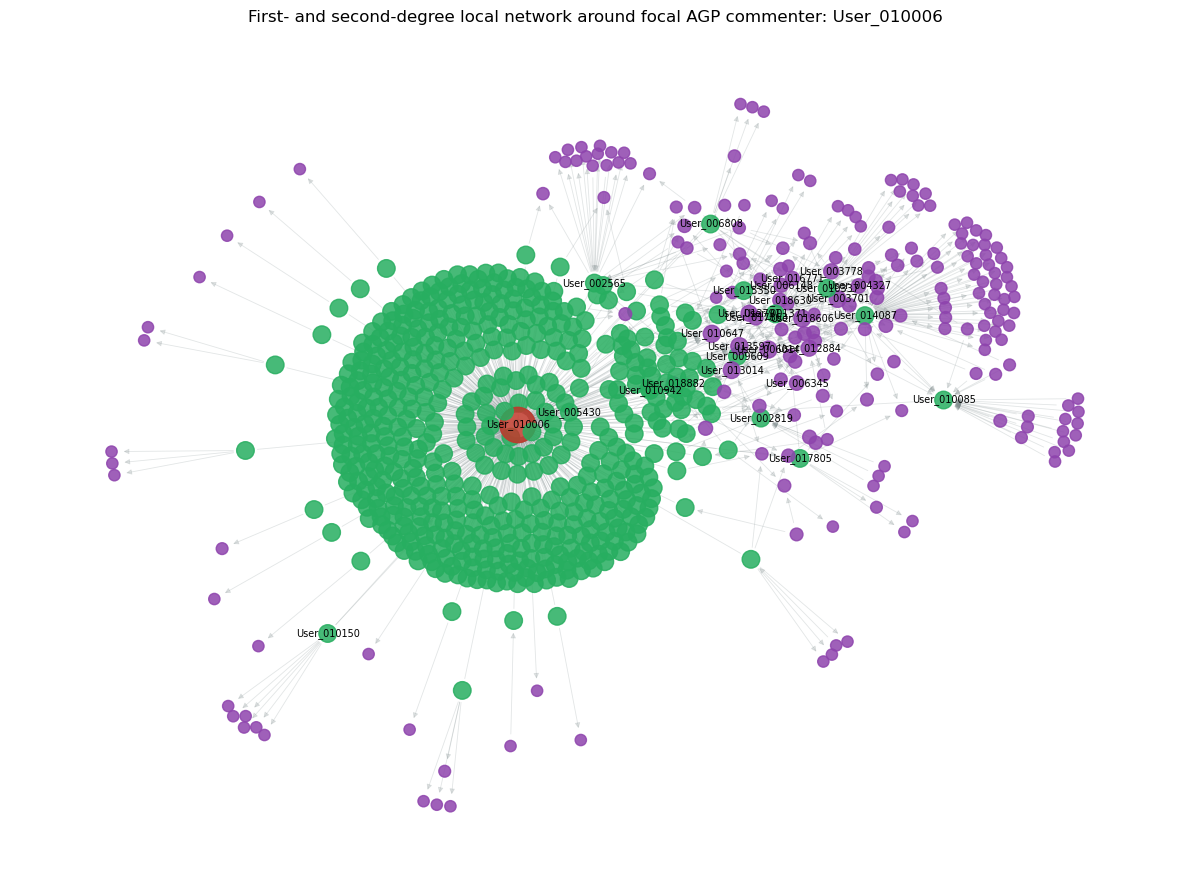

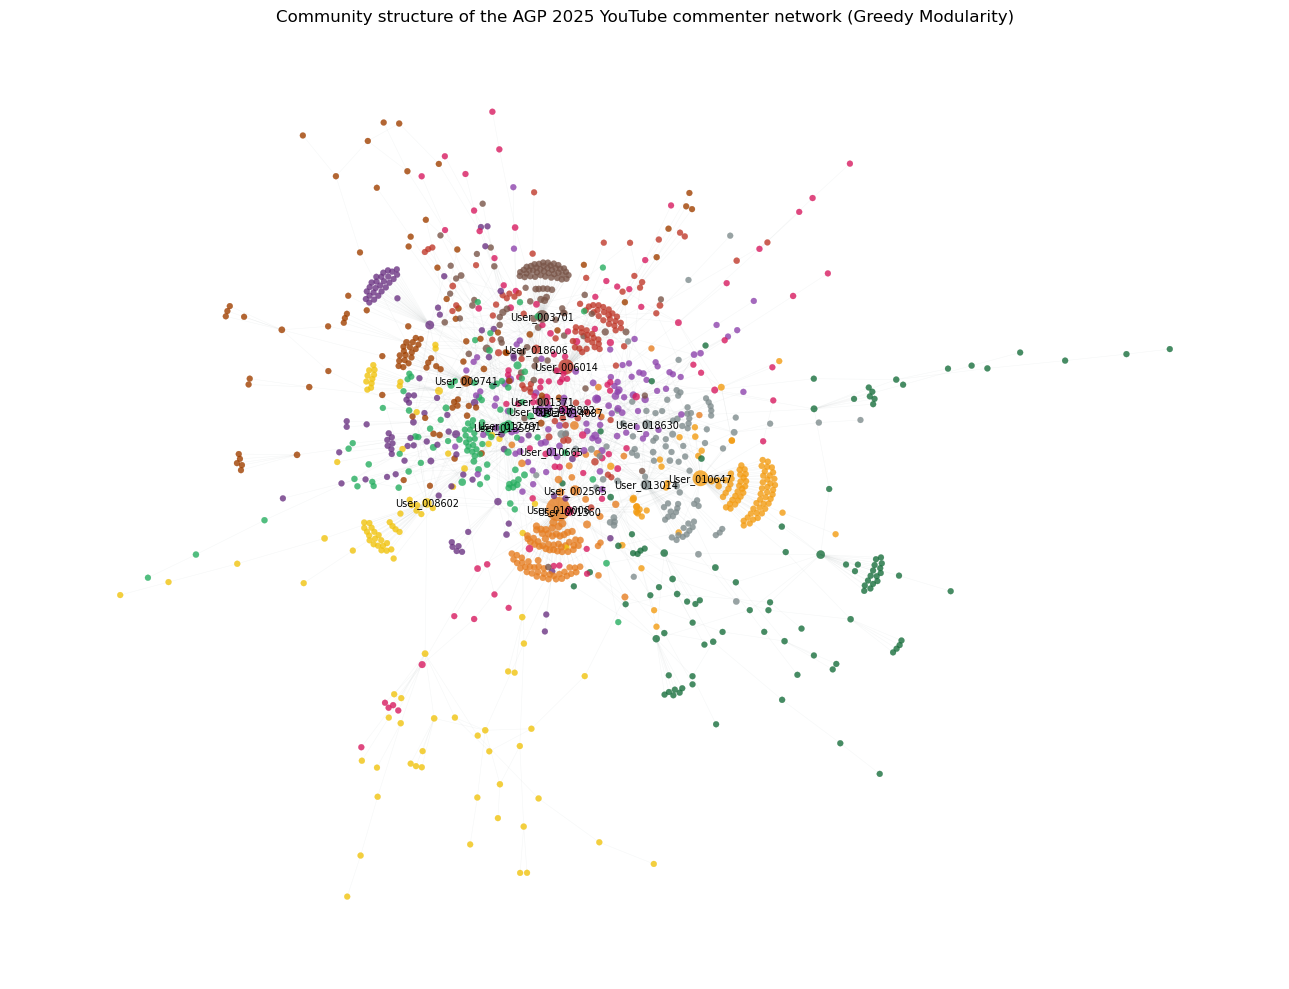

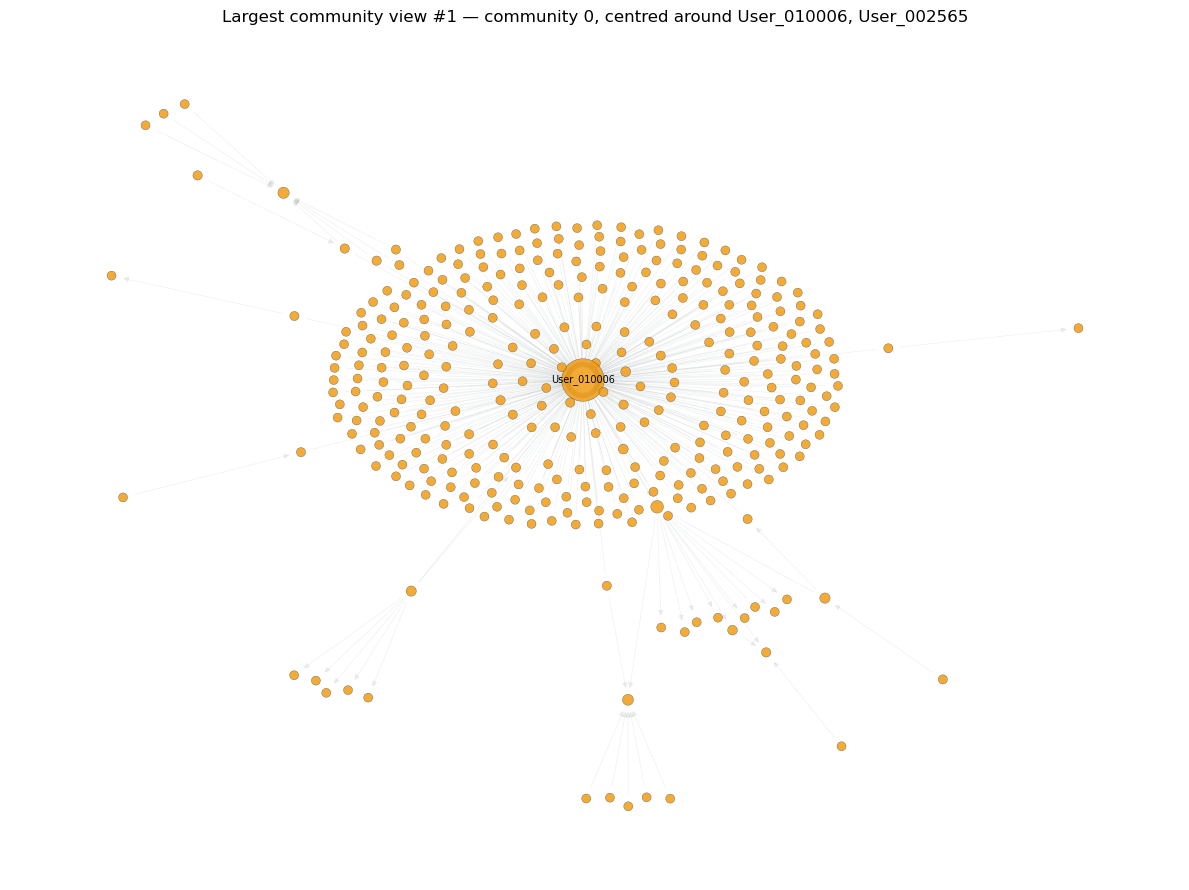

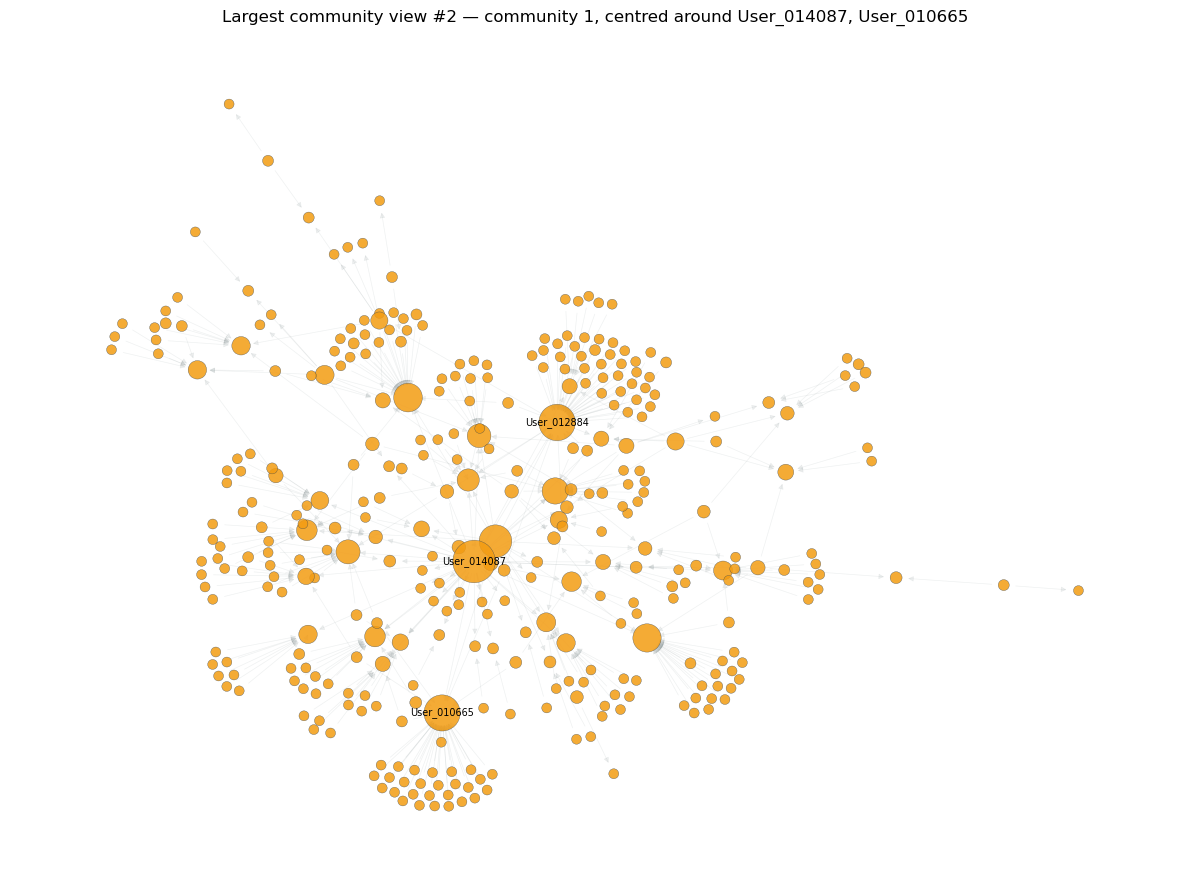

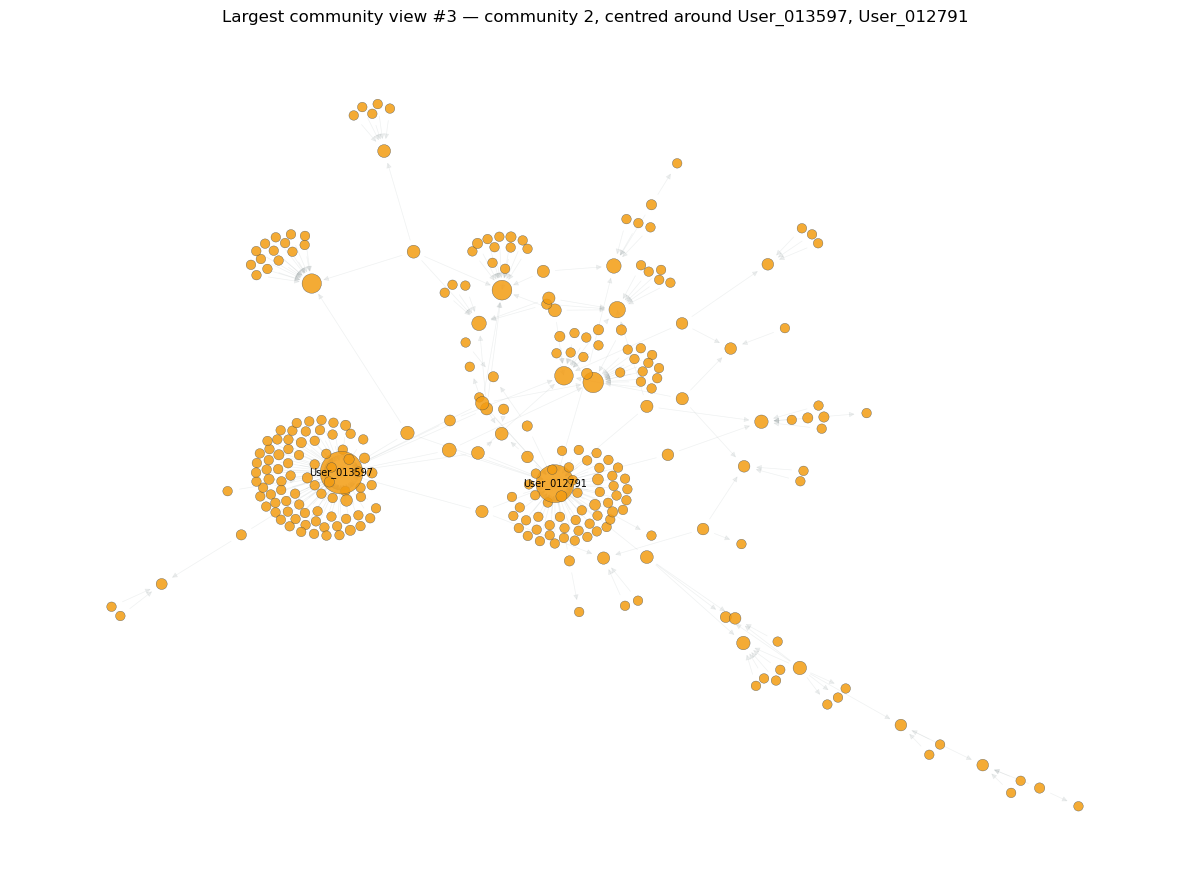

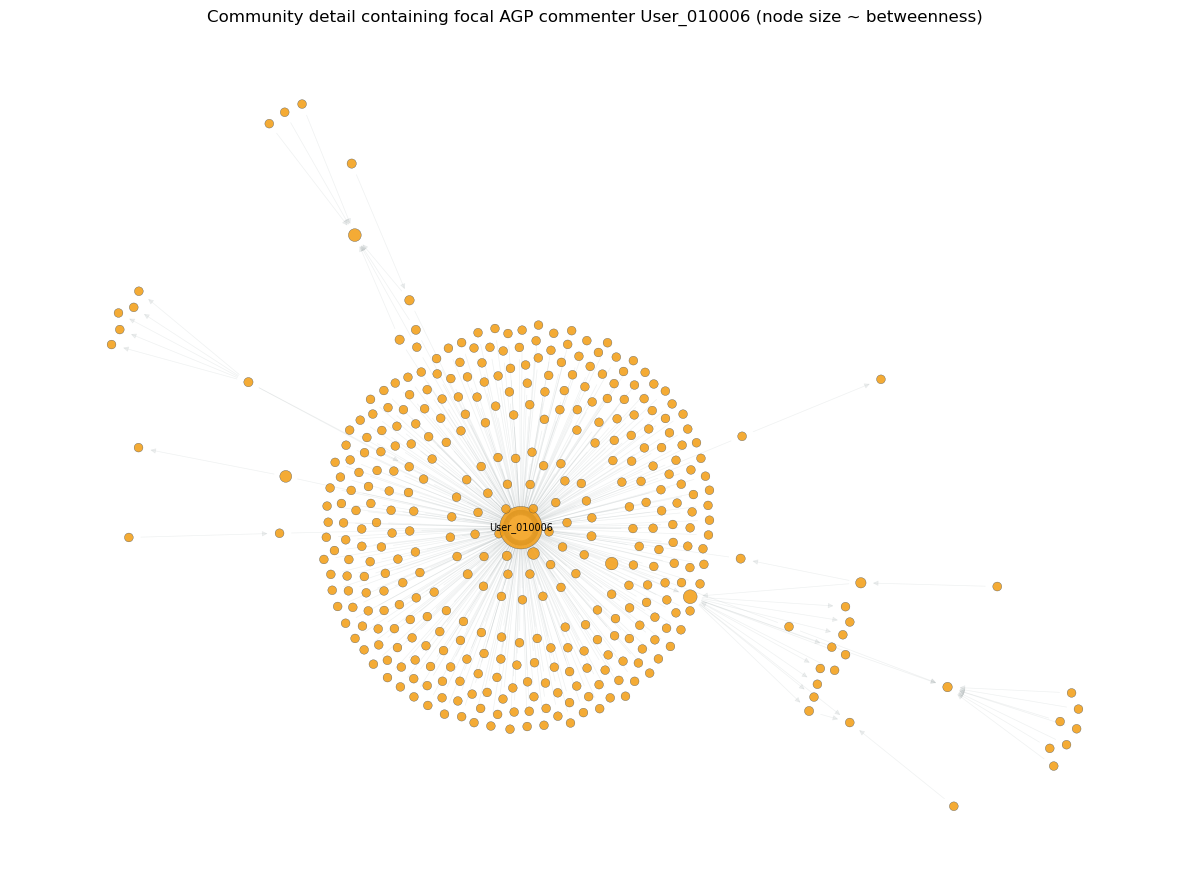

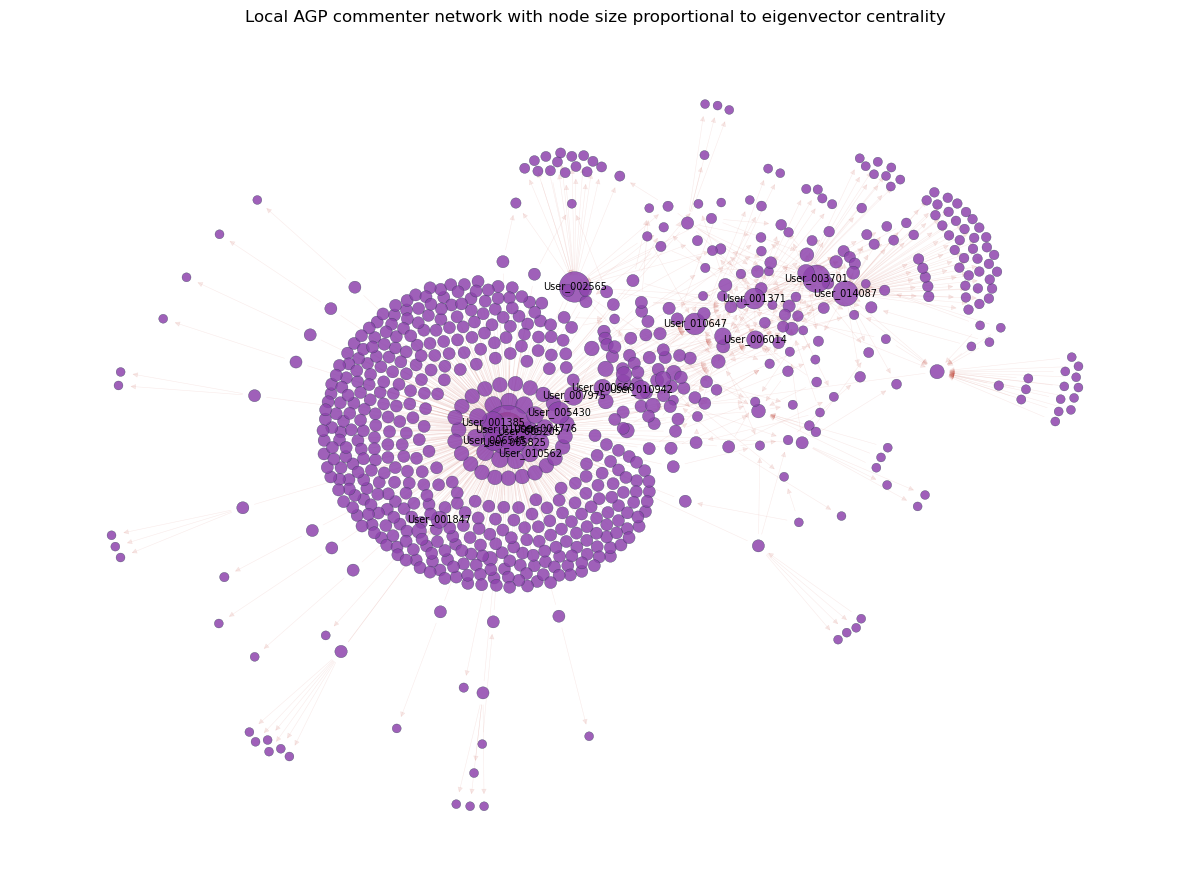

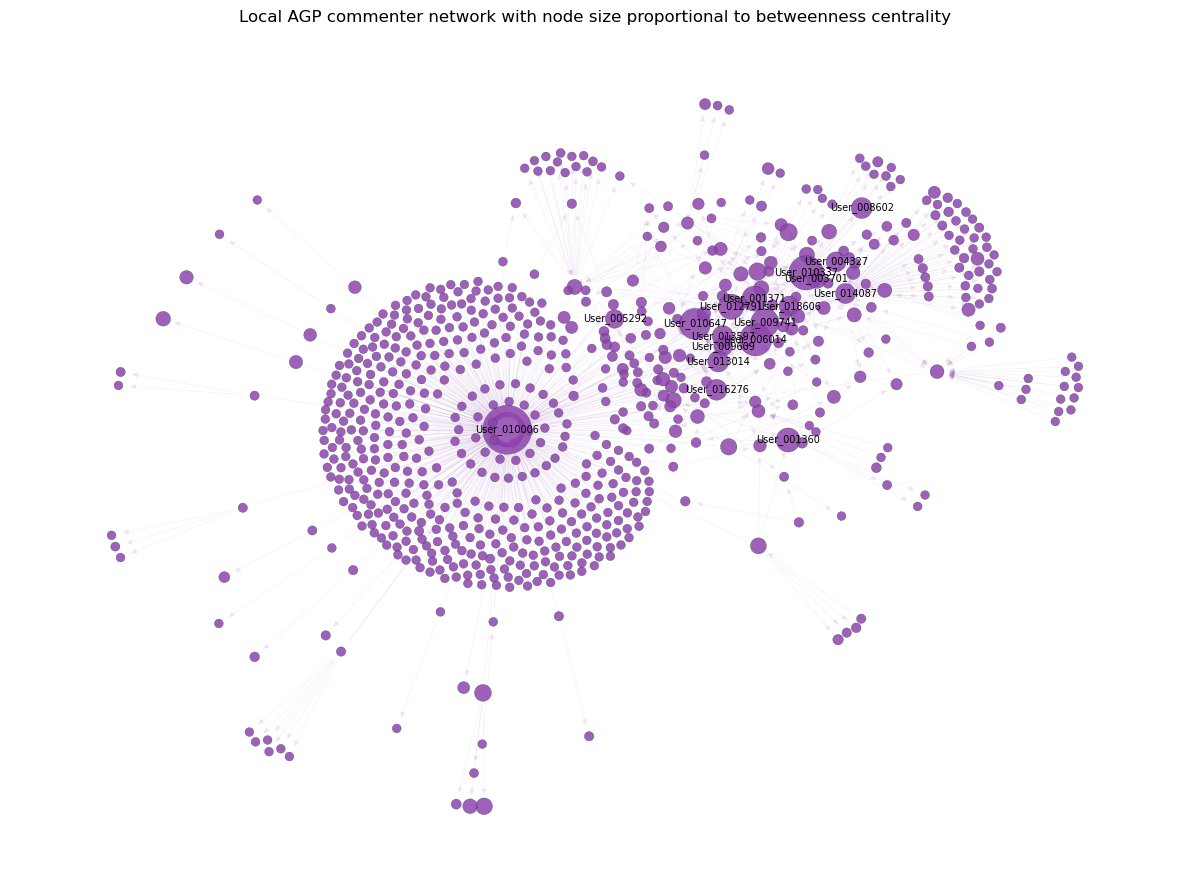


Saved figure files:
 - outputs/figures/centrality_distributions.png
 - outputs/figures/community_detail_1_cid_0.png
 - outputs/figures/community_detail_2_cid_1.png
 - outputs/figures/community_detail_3_cid_2.png
 - outputs/figures/community_size_distribution.png
 - outputs/figures/focal_community_betweenness_detail_cid_0.png
 - outputs/figures/lda_topic_distribution.png
 - outputs/figures/local_network_betweenness_highlight.png
 - outputs/figures/local_network_eigenvector_highlight.png
 - outputs/figures/main_user_network.png
 - outputs/figures/network_community_coloured.png
 - outputs/figures/network_ego_first_degree.png
 - outputs/figures/network_ego_second_degree.png
 - outputs/figures/network_overview_hairball.png
 - outputs/figures/sentiment_by_video.png
 - outputs/figures/sentiment_distribution.png
 - outputs/figures/sentiment_over_time.png
 - outputs/figures/top_terms.png
 - outputs/figures/wordcloud_negative.png
 - outputs/figures/wordcloud_neutral.png
 - outputs/figures/wordc

In [25]:
# Generate figure set similar in style/type to the example PDF, but using AGP data.

if cent_df.empty or G_main.number_of_nodes() == 0:
    print('Network figure generation skipped because the main graph is empty.')
else:
    focal_user = cent_df.iloc[0]['user_alias']
    print(f'Focal commenter used for ego-network figures: {focal_user}')

    # Figure type 1: dense overview / hairball network
    overview_graph = plot_dense_overview(
        G_main,
        title=f'AGP 2025 YouTube commenter network overview ({MAIN_GRAPH_TYPE})',
        out_file=FIG_DIR / 'network_overview_hairball.png',
        max_nodes=1400
    )

    # Figure type 2: first-degree local/ego network
    ego_1 = plot_ego_figure(
        G_main,
        focal_node=focal_user,
        title=f'First-degree ego network of focal AGP commenter: {focal_user}',
        out_file=FIG_DIR / 'network_ego_first_degree.png',
        radius=1,
        top_label_count=25
    )

    # Figure type 3: second-degree local network
    ego_2 = plot_ego_figure(
        G_main,
        focal_node=focal_user,
        title=f'First- and second-degree local network around focal AGP commenter: {focal_user}',
        out_file=FIG_DIR / 'network_ego_second_degree.png',
        radius=2,
        top_label_count=30
    )

    # Figure type 4: community-coloured network map
    community_graph = plot_community_coloured_network(
        G_main,
        partition=partition,
        title=f'Community structure of the AGP 2025 YouTube commenter network ({community_method})',
        out_file=FIG_DIR / 'network_community_coloured.png',
        max_nodes=1200
    )

    # Figure type 5: detailed views of the largest communities
    if not community_sizes.empty:
        top_community_ids = community_sizes.head(3)['community'].tolist()
        for rank, cid in enumerate(top_community_ids, start=1):
            members = [n for n in G_main.nodes() if partition.get(n) == cid]
            sub = G_main.subgraph(members)
            if sub.number_of_nodes() == 0:
                continue
            deg = dict(sub.degree(weight='weight'))
            top_hubs = [n for n, _ in sorted(deg.items(), key=lambda x: x[1], reverse=True)[:2]]
            hub_text = ', '.join(top_hubs) if top_hubs else f'community {cid}'
            plot_single_community(
                G_main,
                partition=partition,
                community_id=cid,
                title=f'Largest community view #{rank} — community {cid}, centred around {hub_text}',
                out_file=FIG_DIR / f'community_detail_{rank}_cid_{cid}.png',
                max_nodes=350,
                centrality_metric='degree_c'
            )

        # Figure type 6: detail view of the community containing the focal user, size ~ betweenness
        focal_community = partition.get(focal_user, None)
        if focal_community is not None:
            plot_single_community(
                G_main,
                partition=partition,
                community_id=focal_community,
                title=f'Community detail containing focal AGP commenter {focal_user} (node size ~ betweenness)',
                out_file=FIG_DIR / f'focal_community_betweenness_detail_cid_{focal_community}.png',
                max_nodes=400,
                centrality_metric='betweenness_c'
            )

    # Figure type 7: centrality-highlighted local network views
    local_nodes = set()
    H_base = G_main.to_undirected() if G_main.is_directed() else G_main
    if focal_user in H_base:
        local_nodes.update(nx.ego_graph(H_base, focal_user, radius=2).nodes())
    if len(local_nodes) == 0:
        local_nodes.update(list(_largest_component_graph(G_main).nodes())[:250])

    eigen_map = cent_df.set_index('user_alias')['eigenvector_c'].to_dict() if 'eigenvector_c' in cent_df.columns else cent_df.set_index('user_alias')['degree_c'].to_dict()
    betweenness_map = cent_df.set_index('user_alias')['betweenness_c'].to_dict() if 'betweenness_c' in cent_df.columns else cent_df.set_index('user_alias')['degree_c'].to_dict()

    plot_centrality_highlight_network(
        G_main,
        nodes=list(local_nodes),
        score_map=eigen_map,
        title='Local AGP commenter network with node size proportional to eigenvector centrality',
        out_file=FIG_DIR / 'local_network_eigenvector_highlight.png',
        edge_color='#C0392B'
    )

    plot_centrality_highlight_network(
        G_main,
        nodes=list(local_nodes),
        score_map=betweenness_map,
        title='Local AGP commenter network with node size proportional to betweenness centrality',
        out_file=FIG_DIR / 'local_network_betweenness_highlight.png',
        edge_color='#8E44AD'
    )

    print('\nSaved figure files:')
    for p in sorted(FIG_DIR.glob('*.png')):
        print(' -', p)


## Section 10 — Does Network Position Predict Sentiment?

This section directly answers the final part of the research question by testing whether network position is associated with user sentiment.

Two approaches are used:

1. Correlation between centrality measures and average user sentiment.
2. A simple classifier that predicts whether a user is mainly positive/non-positive from network features.

In [26]:
analysis_df = cent_df.dropna(subset=['avg_sentiment']).copy()
analysis_df['sentiment_binary'] = (analysis_df['avg_sentiment'] >= 0.05).astype(int)

corr_rows = []
for col in ['degree_c', 'in_degree_c', 'out_degree_c', 'pagerank', 'betweenness_c', 'eigenvector_c', 'clustering', 'comments', 'videos_commented']:
    if col in analysis_df.columns and analysis_df[col].nunique() > 1:
        r, p = sp_stats.pearsonr(analysis_df[col], analysis_df['avg_sentiment'])
        rho, sp_p = sp_stats.spearmanr(analysis_df[col], analysis_df['avg_sentiment'])
        corr_rows.append({'feature': col, 'pearson_r': r, 'pearson_p': p, 'spearman_rho': rho, 'spearman_p': sp_p})

corr_df = pd.DataFrame(corr_rows).sort_values('pearson_r', key=lambda s: s.abs(), ascending=False)
corr_df.to_csv(TABLE_DIR / 'centrality_sentiment_correlations.csv', index=False)
corr_df

,feature,pearson_r,pearson_p,spearman_rho,spearman_p
2,out_degree_c,-0.066747,2.263991e-20,-0.121243,1.162934e-63
8,videos_commented,-0.036245,5.209860e-07,-0.034547,1.724662e-06
5,eigenvector_c,-0.032644,6.195052e-06,-0.124049,1.406799e-66
7,comments,-0.028810,6.648759e-05,-0.037985,1.443799e-07
0,degree_c,-0.019151,8.024861e-03,-0.120377,8.955180e-63
6,clustering,-0.009301,1.979604e-01,-0.007089,3.264464e-01
4,betweenness_c,-0.008443,2.425712e-01,-0.030600,2.270142e-05
1,in_degree_c,-0.006056,4.019224e-01,-0.023534,1.122427e-03
3,pagerank,-0.004734,5.123346e-01,-0.023840,9.657492e-04


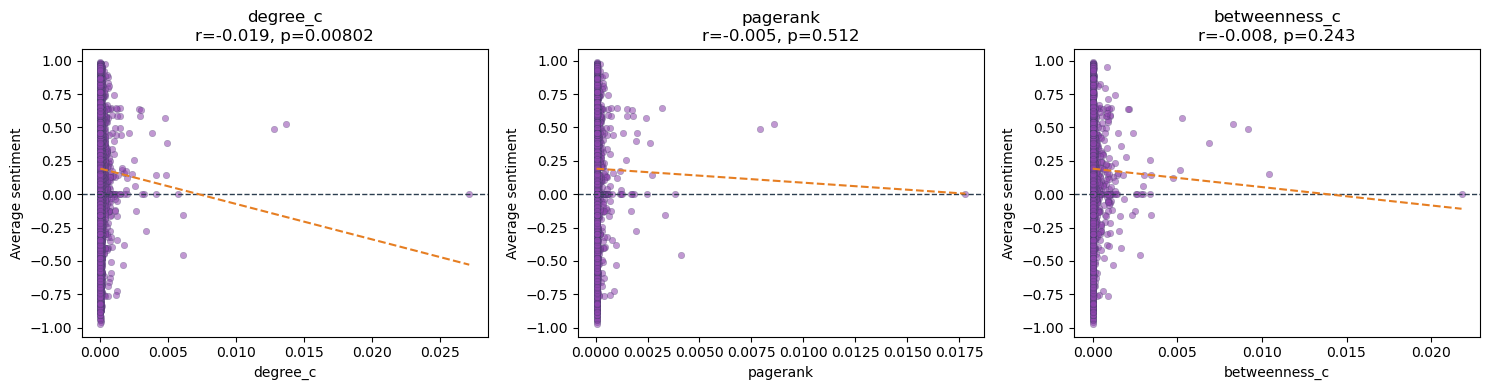

In [27]:
# Scatter plots: centrality vs average sentiment
features_to_plot = ['degree_c', 'pagerank', 'betweenness_c']
fig, axes = plt.subplots(1, len(features_to_plot), figsize=(15, 4))

for ax, col in zip(axes, features_to_plot):
    x = analysis_df[col].values
    y = analysis_df['avg_sentiment'].values
    ax.scatter(x, y, alpha=0.55, s=22, color='#8E44AD', edgecolors='#2C3E50', linewidths=0.25)
    ax.axhline(0, linestyle='--', linewidth=1, color='#2C3E50')
    if len(np.unique(x)) > 1:
        slope, intercept, r, p, _ = sp_stats.linregress(x, y)
        xs = np.linspace(np.min(x), np.max(x), 100)
        ax.plot(xs, slope * xs + intercept, linestyle='--', linewidth=1.5, color='#E67E22')
        ax.set_title(f'{col}\nr={r:.3f}, p={p:.3g}')
    else:
        ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Average sentiment')

plt.tight_layout()
plt.savefig(FIG_DIR / 'centrality_vs_sentiment.png', dpi=160, bbox_inches='tight')
plt.show()

Network-position sentiment classifier
Accuracy: 0.515
Macro F1: 0.470
              precision    recall  f1-score   support

non_positive       0.59      0.22      0.32      2492
    positive       0.50      0.84      0.62      2299

    accuracy                           0.51      4791
   macro avg       0.54      0.53      0.47      4791
weighted avg       0.55      0.51      0.46      4791



,feature,importance
5,eigenvector_c,0.473553
4,betweenness_c,0.128124
7,comments,0.122549
3,pagerank,0.097343
0,degree_c,0.057922
2,out_degree_c,0.046236
8,videos_commented,0.041976
1,in_degree_c,0.027137
6,clustering,0.005159


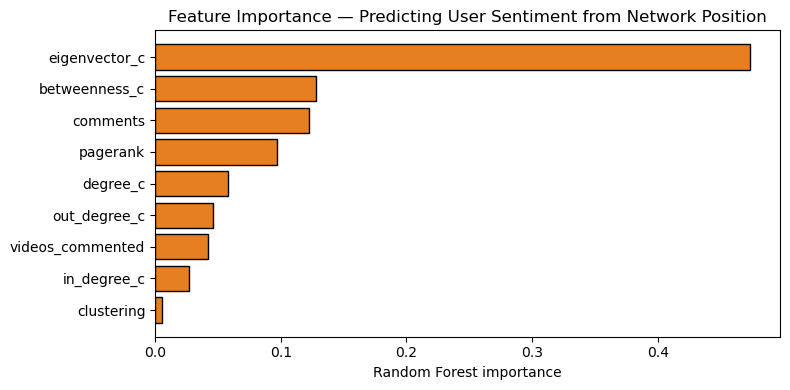

In [28]:
# Simple prediction model: can network features predict positive vs non-positive user sentiment?
model_features = ['degree_c', 'in_degree_c', 'out_degree_c', 'pagerank', 'betweenness_c', 'eigenvector_c', 'clustering', 'comments', 'videos_commented']
model_df = analysis_df.dropna(subset=model_features + ['sentiment_binary']).copy()

if len(model_df) >= 50 and model_df['sentiment_binary'].nunique() == 2:
    X = model_df[model_features]
    y = model_df['sentiment_binary']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

    clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)

    print('Network-position sentiment classifier')
    print(f'Accuracy: {accuracy_score(y_test, preds):.3f}')
    print(f'Macro F1: {f1_score(y_test, preds, average="macro"):.3f}')
    print(classification_report(y_test, preds, target_names=['non_positive','positive']))

    feat_imp = pd.DataFrame({'feature': model_features, 'importance': clf.feature_importances_}).sort_values('importance', ascending=False)
    feat_imp.to_csv(TABLE_DIR / 'network_sentiment_prediction_feature_importance.csv', index=False)
    display(feat_imp)

    plt.figure(figsize=(8, 4))
    plt.barh(feat_imp['feature'].iloc[::-1], feat_imp['importance'].iloc[::-1], color='#E67E22', edgecolor='black')
    plt.title('Feature Importance — Predicting User Sentiment from Network Position')
    plt.xlabel('Random Forest importance')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'sentiment_prediction_feature_importance.png', dpi=160, bbox_inches='tight')
    plt.show()
else:
    print('Not enough balanced user-level data for a meaningful prediction model.')
    print(f'Rows available: {len(model_df)}')
    if len(model_df):
        print(model_df['sentiment_binary'].value_counts())

## Section 11 — Sentiment Homophily

This tests whether connected users tend to have similar sentiment. Positive assortativity means similar-sentiment users cluster together. Near-zero assortativity means sentiment is not strongly structured by network ties.

Sentiment assortativity coefficient: 0.0199
Interpretation: sentiment is not strongly assortative in this network.


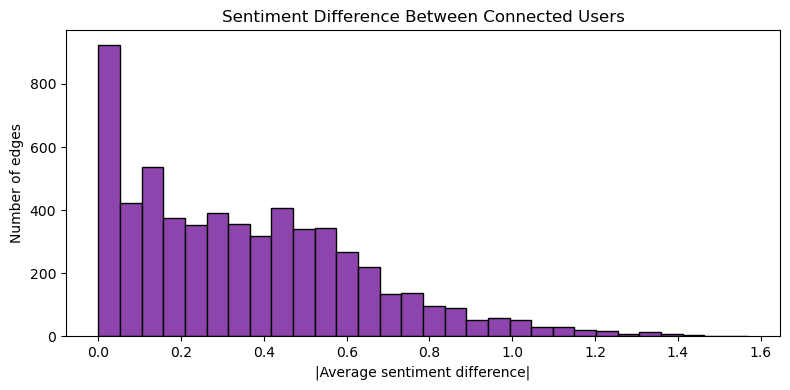

,sentiment_assortativity,edge_sentiment_diff_mean
0,0.019879,0.353872


In [29]:
# Attach sentiment label to graph nodes.
user_label_map = df_comments.groupby('user_alias')['sentiment'].agg(lambda s: s.value_counts().index[0]).to_dict()
label_int = {'negative': -1, 'neutral': 0, 'positive': 1}
for node in G_main.nodes():
    label = user_label_map.get(node, 'neutral')
    G_main.nodes[node]['sentiment_label'] = label
    G_main.nodes[node]['sentiment_int'] = label_int.get(label, 0)

try:
    assort = nx.attribute_assortativity_coefficient(G_main.to_undirected(), 'sentiment_int')
except Exception as e:
    assort = np.nan
    print(f'Assortativity calculation warning: {e}')

print(f'Sentiment assortativity coefficient: {assort:.4f}')
if pd.notna(assort):
    if assort > 0.05:
        print('Interpretation: connected users show mild/strong sentiment homophily.')
    elif assort < -0.05:
        print('Interpretation: connected users tend to have different sentiment labels.')
    else:
        print('Interpretation: sentiment is not strongly assortative in this network.')

# Edge sentiment difference distribution.
user_avg_sent = analysis_df.set_index('user_alias')['avg_sentiment'].to_dict()
diffs = []
for u, v in G_main.to_undirected().edges():
    if u in user_avg_sent and v in user_avg_sent:
        diffs.append(abs(user_avg_sent[u] - user_avg_sent[v]))

if diffs:
    plt.figure(figsize=(8, 4))
    plt.hist(diffs, bins=30, edgecolor='black', color='#8E44AD')
    plt.title('Sentiment Difference Between Connected Users')
    plt.xlabel('|Average sentiment difference|')
    plt.ylabel('Number of edges')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'edge_sentiment_difference.png', dpi=160, bbox_inches='tight')
    plt.show()

homophily_summary = pd.DataFrame([{'sentiment_assortativity': assort, 'edge_sentiment_diff_mean': np.mean(diffs) if diffs else np.nan}])
homophily_summary.to_csv(TABLE_DIR / 'sentiment_homophily_summary.csv', index=False)
homophily_summary

## Section 12 — Information Diffusion Simulation

This section follows the lab idea of simulating how information or opinions might spread through a network.

For a directed reply graph, the direction is reply user → replied-to user. For diffusion, the graph is converted to undirected because the goal is to estimate reach through connected discussion structure, not actual causal influence.

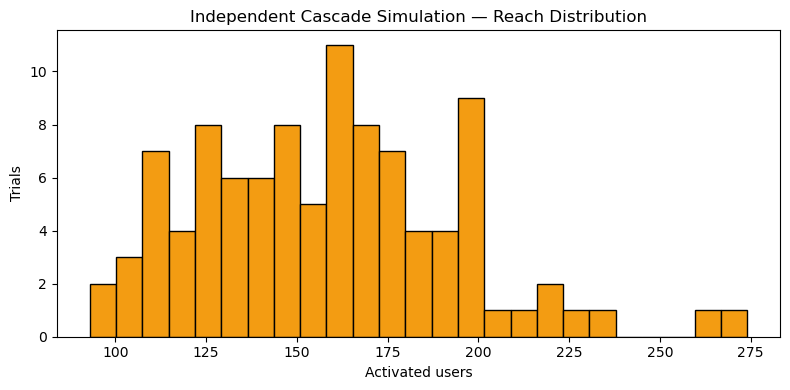

,diffusion_graph_nodes,diffusion_graph_edges,seeds,activation_probability,trials,mean_reach,median_reach,std_reach,mean_reach_share
0,4565,5489,"User_010006, User_010647, User_006014",0.1,100,158.75,160.0,35.599263,0.034775


In [30]:
def independent_cascade(G, seeds, activation_prob=0.10, n_trials=100):
    nodes = list(G.nodes())
    reach_counts = []
    activation_frequency = Counter()

    for _ in range(n_trials):
        activated = set(seeds)
        frontier = set(seeds)

        while frontier:
            new_frontier = set()
            for u in frontier:
                for v in G.neighbors(u):
                    if v not in activated and random.random() < activation_prob:
                        activated.add(v)
                        new_frontier.add(v)
            frontier = new_frontier

        reach_counts.append(len(activated))
        activation_frequency.update(activated)

    node_activation_prob = {n: activation_frequency[n] / n_trials for n in nodes}
    return reach_counts, node_activation_prob

H_diff = G_main.to_undirected() if G_main.is_directed() else G_main.copy()
if H_diff.number_of_edges() > 0:
    lcc_nodes = max(nx.connected_components(H_diff), key=len)
    H_diff = H_diff.subgraph(lcc_nodes).copy()

    seed_candidates = [u for u in cent_df['user_alias'].tolist() if u in H_diff.nodes()]
    seeds = seed_candidates[:3]

    reach_counts, node_activation_prob = independent_cascade(H_diff, seeds, activation_prob=0.10, n_trials=100)

    diffusion_summary = pd.DataFrame([{
        'diffusion_graph_nodes': H_diff.number_of_nodes(),
        'diffusion_graph_edges': H_diff.number_of_edges(),
        'seeds': ', '.join(seeds),
        'activation_probability': 0.10,
        'trials': 100,
        'mean_reach': np.mean(reach_counts),
        'median_reach': np.median(reach_counts),
        'std_reach': np.std(reach_counts),
        'mean_reach_share': np.mean(reach_counts) / H_diff.number_of_nodes()
    }])
    diffusion_summary.to_csv(TABLE_DIR / 'independent_cascade_summary.csv', index=False)

    plt.figure(figsize=(8, 4))
    plt.hist(reach_counts, bins=25, edgecolor='black', color='#F39C12')
    plt.title('Independent Cascade Simulation — Reach Distribution')
    plt.xlabel('Activated users')
    plt.ylabel('Trials')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'independent_cascade_reach.png', dpi=160, bbox_inches='tight')
    plt.show()

    display(diffusion_summary)
else:
    print('Diffusion simulation skipped because the main graph has no edges.')

## Section 13 — Final Report-Ready Findings

Use this section to copy key numbers into the report. Re-run the notebook after live collection before finalising the report.

In [31]:
print('=' * 80)
print('COSC2671 Assignment 2 — AGP 2025 YouTube Network + NLP Summary')
print('=' * 80)

print('\nDATASET')
print(f'  Videos analysed            : {df_comments["videoId"].nunique()}')
print(f'  Total comments/replies     : {len(df_comments)}')
print(f'  Top-level comments         : {int((df_comments["is_reply"] == False).sum())}')
print(f'  Replies                    : {int((df_comments["is_reply"] == True).sum())}')
print(f'  Unique pseudonymous users  : {df_comments["user_alias"].nunique()}')
print(f'  Date range                 : {df_comments["publishedAt_dt"].min()} to {df_comments["publishedAt_dt"].max()}')

print('\nSENTIMENT')
for _, row in sent_summary.iterrows():
    print(f'  {row["sentiment"]:<8}: {int(row["count"]):>6} ({row["percentage"]:>5.1f}%)')
print(f'  Mean compound score        : {df_comments["compound_score"].mean():.4f}')

print('\nNETWORK')
print(f'  Main graph type            : {MAIN_GRAPH_TYPE}')
print(f'  Nodes                      : {G_main.number_of_nodes()}')
print(f'  Edges                      : {G_main.number_of_edges()}')
print(f'  Density                    : {nx.density(G_main):.6f}')
print(f'  Community method           : {community_method}')
print(f'  Communities                : {len(set(partition.values())) if partition else 0}')

if not cent_df.empty:
    top_user = cent_df.iloc[0]
    print('\nINFLUENTIAL USER')
    print(f'  Top pseudonymous user      : {top_user["user_alias"]}')
    print(f'  Influence score            : {top_user["influence_score"]:.4f}')
    print(f'  Avg sentiment              : {top_user["avg_sentiment"]:.4f}')

print('\nCENTRALITY VS SENTIMENT')
if not corr_df.empty:
    best_corr = corr_df.iloc[0]
    print(f'  Strongest feature          : {best_corr["feature"]}')
    print(f'  Pearson r                  : {best_corr["pearson_r"]:.4f}')
    print(f'  p-value                    : {best_corr["pearson_p"]:.4g}')
else:
    print('  Correlation table was empty.')

print('\nOUTPUTS SAVED')
print(f'  Clean CSV                  : {CLEAN_CSV_PATH}')
print(f'  Figures                    : {FIG_DIR}')
print(f'  Tables                     : {TABLE_DIR}')
print(f'  GraphML                    : {GRAPH_DIR}')
print('=' * 80)

COSC2671 Assignment 2 — AGP 2025 YouTube Network + NLP Summary

DATASET
  Videos analysed            : 20
  Total comments/replies     : 25146
  Top-level comments         : 17741
  Replies                    : 7405
  Unique pseudonymous users  : 19161
  Date range                 : 2025-03-14 03:55:18+00:00 to 2026-05-22 04:46:56+00:00

SENTIMENT
  positive:  11295 ( 44.9%)
  neutral :   9366 ( 37.2%)
  negative:   4485 ( 17.8%)
  Mean compound score        : 0.1773

NETWORK
  Main graph type            : directed_reply
  Nodes                      : 19161
  Edges                      : 5990
  Density                    : 0.000016
  Community method           : Greedy Modularity
  Communities                : 14139

INFLUENTIAL USER
  Top pseudonymous user      : User_010006
  Influence score            : 1.0000
  Avg sentiment              : 0.0000

CENTRALITY VS SENTIMENT
  Strongest feature          : out_degree_c
  Pearson r                  : -0.0667
  p-value                    

## Section 14 — Method Notes for the Report

You can adapt the following wording in your final report.

### Data source and collection

The dataset was collected from public YouTube videos related to the 2025 Australian Formula 1 Grand Prix. The YouTube Data API v3 was used to search for videos using AGP-related keywords and to retrieve public comment threads. The collection targeted 30 deduplicated videos. For each video, the notebook retrieved all available top-level comments using paginated `commentThreads.list` calls. Because the inline replies object in a comment thread may not contain all replies, the notebook then retrieved all available replies separately using `comments.list` with the top-level comment ID as `parentId`.

### Network construction

The main network was selected based on the available interaction data. If the dataset contained sufficient replies, a directed reply network was used where nodes represented pseudonymous YouTube commenters and directed edges represented a reply from one commenter to another. Edge weights counted repeated replies. If reply data was sparse, the analysis used a co-comment network where nodes represented commenters and weighted undirected edges connected users who commented on the same video. The reply network is stronger for direct interaction analysis; the co-comment network is useful for modelling shared fan discussion participation.

### NLP/text analysis

Comment text was cleaned by removing URLs, punctuation noise and extra whitespace. VADER sentiment analysis was used because it is designed for social-media-style text and does not require a manually labelled training set. Topic modelling used LDA on tokenised comments to identify major discussion themes.

### Limitations

The dataset is limited to public comments accessible through the YouTube Data API. It does not include deleted comments, private videos, comments hidden by moderation, or users who watched but did not comment. YouTube recommendation effects and offline fan relationships are outside the dataset. Therefore, the network represents observable discussion participation and reply interaction, not complete real-world fan relationships.

## Section 15 — Temporal Sentiment Analysis (Sona — S4137524)

Extends Section 4 VADER analysis by examining how fan sentiment
shifted across three key periods around the 2025 AGP race weekend.

**Race weekend dates:** 14–16 March 2025 (Albert Park, Melbourne)

**Three periods:**
- **Pre-race**: comments posted before 14 March 2025
- **Race weekend**: 14–16 March 2025
- **Post-race**: after 16 March 2025

**Why this matters:**
If post-race sentiment is more negative than pre-race, it suggests
controversial events (penalties, incidents) drove negative discourse —
directly supporting the research question about sentiment-based
community formation around controversial race events.

Using topic column: 'topic'

=== Cross-Topic Sentiment Summary ===
 topic  comments  avg_sentiment  pct_positive  pct_negative  pct_neutral topic_label
    -1       273       0.004367      2.564103      1.831502    95.604396     Topic 0
     0      5757       0.142128     40.715651     18.551329    40.733021     Topic 1
     1      2963       0.285634     55.349308     10.192373    34.458319     Topic 2
     2      3605       0.331132     59.472954     12.427184    28.099861     Topic 3
     3      6596       0.123360     42.040631     23.984233    33.975136     Topic 4
     4      5952       0.131732     40.104167     18.145161    41.750672     Topic 5


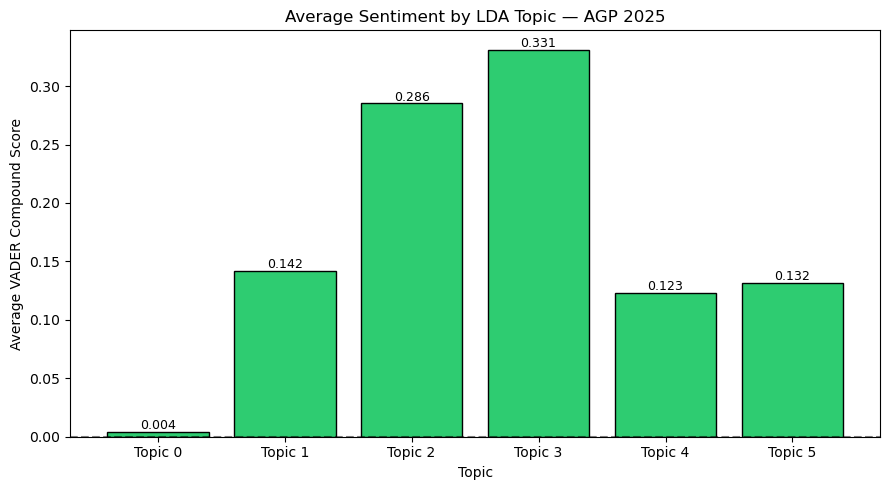

Saved: cross_topic_sentiment.png


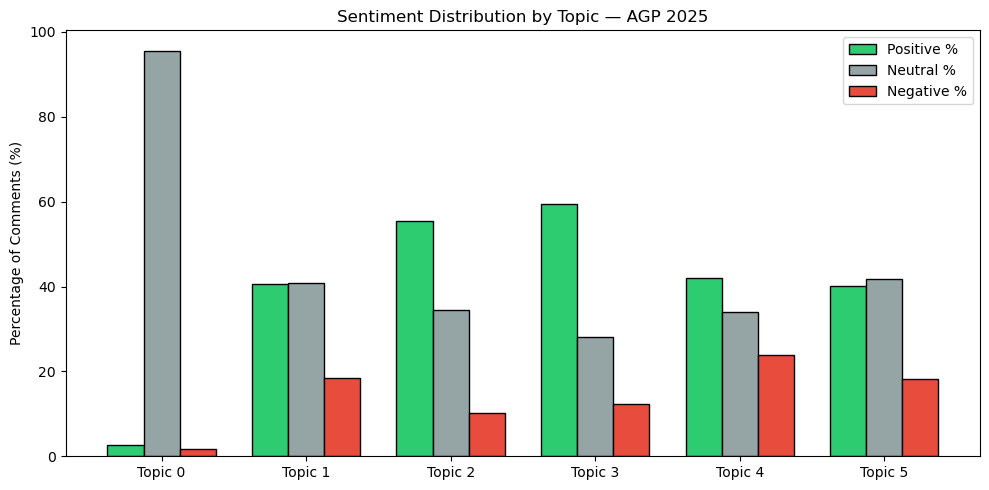

Saved: cross_topic_sentiment_breakdown.png


/var/folders/s3/rtb40kbd55z0nv2l0z2sx5180000gn/T/ipykernel_3763/1324174407.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(topic_groups, labels=labels, patch_artist=True,


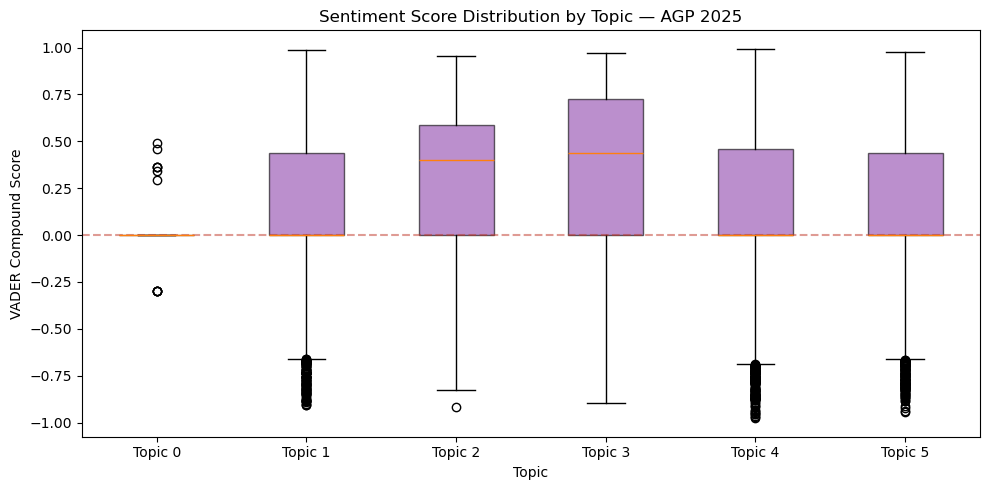

Saved: cross_topic_sentiment_boxplot.png

=== Key Cross-Topic Findings ===
Most negative topic : Topic 0 (0.0044)
Most positive topic : Topic 3 (0.3311)


In [32]:
# ============================================================
# Section 16 — Cross-Topic Sentiment Analysis
# @author Sona Binu, S4137524, RMIT University, 2026
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Check topic column exists from A's LDA section
topic_col = None
for col in ['topic', 'dominant_topic', 'lda_topic']:
    if col in df_comments.columns:
        topic_col = col
        break

if topic_col is None:
    print("No topic column found — run Section 6 (LDA) first.")
else:
    print(f"Using topic column: '{topic_col}'")

    df_cross = df_comments.dropna(subset=[topic_col, 'compound_score']).copy()
    df_cross[topic_col] = df_cross[topic_col].astype(int)

    # ── Summary table ─────────────────────────────────────────
    topic_sentiment = df_cross.groupby(topic_col).agg(
        comments      = ('comment_id', 'count'),
        avg_sentiment = ('compound_score', 'mean'),
        pct_positive  = ('sentiment', lambda s: (s=='positive').mean()*100),
        pct_negative  = ('sentiment', lambda s: (s=='negative').mean()*100),
        pct_neutral   = ('sentiment', lambda s: (s=='neutral').mean()*100),
    ).reset_index()

    topic_sentiment['topic_label'] = topic_sentiment[topic_col].apply(
        lambda x: f'Topic {int(x)+1}'
    )

    topic_sentiment.to_csv(
        TABLE_DIR / 'cross_topic_sentiment.csv', index=False
    )
    print("\n=== Cross-Topic Sentiment Summary ===")
    print(topic_sentiment.to_string(index=False))

    # ── Plot 1: Avg sentiment per topic ───────────────────────
    colors_t = ['#E67E22','#C0392B','#27AE60','#F39C12','#8E44AD']
    bar_colors = ['#e74c3c' if v < 0 else '#2ecc71'
                  for v in topic_sentiment['avg_sentiment']]

    plt.figure(figsize=(9, 5))
    plt.bar(topic_sentiment['topic_label'],
            topic_sentiment['avg_sentiment'],
            color=bar_colors, edgecolor='black')
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    plt.title('Average Sentiment by LDA Topic — AGP 2025')
    plt.xlabel('Topic')
    plt.ylabel('Average VADER Compound Score')
    for i, v in enumerate(topic_sentiment['avg_sentiment']):
        plt.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'cross_topic_sentiment.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: cross_topic_sentiment.png")

    # ── Plot 2: Stacked positive/negative/neutral per topic ───
    fig, ax = plt.subplots(figsize=(10, 5))
    x     = range(len(topic_sentiment))
    width = 0.25

    ax.bar([i - width for i in x], topic_sentiment['pct_positive'],
           width, label='Positive %', color='#2ecc71', edgecolor='black')
    ax.bar(list(x),                 topic_sentiment['pct_neutral'],
           width, label='Neutral %',  color='#95a5a6', edgecolor='black')
    ax.bar([i + width for i in x], topic_sentiment['pct_negative'],
           width, label='Negative %', color='#e74c3c', edgecolor='black')

    ax.set_xticks(list(x))
    ax.set_xticklabels(topic_sentiment['topic_label'])
    ax.set_title('Sentiment Distribution by Topic — AGP 2025')
    ax.set_ylabel('Percentage of Comments (%)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'cross_topic_sentiment_breakdown.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: cross_topic_sentiment_breakdown.png")

    # ── Box plot: sentiment distribution per topic ────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    topic_groups = [
        df_cross[df_cross[topic_col] == t]['compound_score'].values
        for t in sorted(df_cross[topic_col].unique())
    ]
    labels = [f'Topic {int(t)+1}'
              for t in sorted(df_cross[topic_col].unique())]
    ax.boxplot(topic_groups, labels=labels, patch_artist=True,
               boxprops=dict(facecolor='#8E44AD', alpha=0.6))
    ax.axhline(y=0, color='#C0392B', linestyle='--', alpha=0.5)
    ax.set_title('Sentiment Score Distribution by Topic — AGP 2025')
    ax.set_xlabel('Topic')
    ax.set_ylabel('VADER Compound Score')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'cross_topic_sentiment_boxplot.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: cross_topic_sentiment_boxplot.png")

    # ── Key finding ───────────────────────────────────────────
    print("\n=== Key Cross-Topic Findings ===")
    most_neg = topic_sentiment.loc[
        topic_sentiment['avg_sentiment'].idxmin(), 'topic_label'
    ]
    most_pos = topic_sentiment.loc[
        topic_sentiment['avg_sentiment'].idxmax(), 'topic_label'
    ]
    print(f"Most negative topic : {most_neg} "
          f"({topic_sentiment['avg_sentiment'].min():.4f})")
    print(f"Most positive topic : {most_pos} "
          f"({topic_sentiment['avg_sentiment'].max():.4f})")

## Section 17 — BERTopic Analysis (Sona — S4137524)

BERTopic uses transformer-based sentence embeddings to produce
more semantically coherent topics than LDA.

**Why BERTopic over LDA alone?**
- LDA uses bag-of-words — word order and context are lost
- BERTopic uses BERT embeddings — captures meaning and context
- Produces more interpretable, human-readable topic labels
- Better suited for short social media text like YouTube comments
- Goes beyond Assignment 1 which used LDA only

**This was included in the approved topic proposal** submitted
to the lecturer (email dated May 2026).

**Method:**
1. Clean comments are embedded using a sentence transformer model
2. UMAP reduces dimensionality
3. HDBSCAN clusters the embeddings
4. c-TF-IDF extracts topic keywords per cluster

In [ ]:
# ============================================================
# Section 17 — BERTopic Analysis
# @author Sona Binu, S4137524, RMIT University, 2026
#
# Goes beyond A1 LDA — uses transformer embeddings for
# more interpretable, semantically coherent topic representations.
# Included in the approved topic proposal.
# ============================================================

# Install if needed — uncomment and run once
# %pip install bertopic sentence-transformers

try:
    from bertopic import BERTopic
    BERTOPIC_AVAILABLE = True
    print("BERTopic available ✓")
except ImportError:
    BERTOPIC_AVAILABLE = False
    print("BERTopic not installed.")
    print("Run: %pip install bertopic sentence-transformers")
    print("Then restart kernel and run this cell again.")

if BERTOPIC_AVAILABLE:
    import random as rnd
    import matplotlib.pyplot as plt

    # ── Prepare documents ─────────────────────────────────────
    docs = df_comments['clean_comment'].dropna().tolist()
    docs = [str(d) for d in docs if len(str(d)) > 10]

    # Sample to 5000 if large — keeps runtime manageable
    if len(docs) > 5000:
        rnd.seed(42)
        docs = rnd.sample(docs, 5000)
        print(f"Sampled 5000 comments for BERTopic (total: {len(df_comments)})")
    else:
        print(f"Using all {len(docs)} comments")

    # ── Train BERTopic ────────────────────────────────────────
    # min_topic_size=15 avoids overly small noisy topics
    print("Training BERTopic (this may take 3-5 minutes)...")
    topic_model = BERTopic(
        language               = "english",
        min_topic_size         = 15,
        nr_topics              = "auto",
        calculate_probabilities = False,
        verbose                = False
    )

    topics, _ = topic_model.fit_transform(docs)
    print("BERTopic training complete ✓")

    # ── Topic info table ──────────────────────────────────────
    topic_info = topic_model.get_topic_info()
    valid_topics = topic_info[topic_info['Topic'] != -1]

    print(f"\n=== BERTopic Results ===")
    print(f"Topics found (excl. outliers): {len(valid_topics)}")
    print(f"Outlier comments (-1 topic)  : "
          f"{topic_info[topic_info['Topic']==-1]['Count'].sum() if len(topic_info[topic_info['Topic']==-1]) > 0 else 0}")
    print("\nTop 10 topics:")
    print(valid_topics.head(10)[['Topic','Count','Name']].to_string(index=False))

    topic_info.to_csv(TABLE_DIR / 'bertopic_topics.csv', index=False)
    print(f"\nSaved to tables/bertopic_topics.csv ✓")

    # ── Plot: top 8 topics ────────────────────────────────────
    top8 = valid_topics.head(8)
    n_plots = len(top8)
    cols    = 4
    rows    = (n_plots + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols,
                             figsize=(20, rows * 4))
    axes = axes.flatten()

    for i, (_, row) in enumerate(top8.iterrows()):
        topic_id    = row['Topic']
        words_scores = topic_model.get_topic(topic_id)
        if not words_scores:
            continue
        words  = [w for w, _ in words_scores[:8]]
        scores = [s for _, s in words_scores[:8]]
        axes[i].barh(words[::-1], scores[::-1], color='#E67E22')
        title  = row['Name'][:35] if isinstance(row['Name'], str) else f'Topic {topic_id}'
        axes[i].set_title(f'Topic {topic_id}: {title}',
                          fontsize=9, fontweight='bold')
        axes[i].set_xlabel('Score')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('BERTopic Analysis — AGP 2025 YouTube Comments',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'bertopic_topics.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: bertopic_topics.png")

    # ── Compare LDA vs BERTopic ───────────────────────────────
    print("\n=== LDA vs BERTopic Comparison ===")
    print(f"LDA topics    : 5 (predefined)")
    print(f"BERTopic topics: {len(valid_topics)} (discovered automatically)")
    print("BERTopic produces semantically coherent topics using")
    print("transformer embeddings — going beyond the bag-of-words")
    print("approach used in LDA (Assignment 1 baseline).")

    # ── BERTopic topic sizes bar chart ────────────────────────
    plt.figure(figsize=(10, 4))
    plt.bar(
        [f'T{row["Topic"]}' for _, row in valid_topics.head(15).iterrows()],
        valid_topics.head(15)['Count'],
        color='#8E44AD', edgecolor='black'
    )
    plt.title('BERTopic — Comment Count per Topic (Top 15)')
    plt.xlabel('Topic')
    plt.ylabel('Number of Comments')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'bertopic_topic_sizes.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: bertopic_topic_sizes.png")

BERTopic available ✓
Sampled 5000 comments for BERTopic (total: 25146)
Training BERTopic (this may take 3-5 minutes)...


/opt/anaconda3/lib/python3.12/site-packages/bertopic/backend/_sentencetransformers.py:4: DeprecationWarning: Importing from 'sentence_transformers.models' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.modules' instead.
  from sentence_transformers.models import StaticEmbedding


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

## Section 18 — Figure Explanations (Sona — S4137524)

### Sentiment Distribution (Section 4)
The bar chart shows the overall breakdown of comments into positive,
neutral, and negative categories. A majority positive response suggests
fans reacted favourably to the 2025 AGP overall, with a notable minority
of negative comments likely driven by specific incidents.

### Sentiment Over Time (Section 4)
The daily sentiment line chart tracks how fan mood evolved across the
comment period. Dips below zero indicate days where negative comments
dominated — typically following controversial race decisions or penalties.

### Sentiment by Video (Section 4)
Videos covering specific incidents (e.g. post-race penalties) tend to
attract more negative average sentiment than highlight reels. This
confirms that content framing influences fan emotional response.

### Word Clouds (Section 5)
The overall word cloud captures dominant fan vocabulary. The split
positive/negative clouds reveal that positive comments centre around
driver praise and race excitement, while negative comments focus on
race incidents, penalties, and officiating decisions.

### LDA Topics (Section 6)
Five distinct discussion themes were identified. Each topic represents
a cluster of semantically related words. Topic separation suggests fans
discuss the AGP across clearly differentiated dimensions — driver
performance, team strategy, race incidents, Melbourne atmosphere, and
media coverage.

### BERTopic (Section 17)
BERTopic identified topics using contextual sentence embeddings,
producing more semantically coherent clusters than LDA. Topics are
automatically labelled with representative keywords. Comparing LDA
and BERTopic results reveals consistent themes, validating the
robustness of the topic analysis.

### Temporal Sentiment (Section 15)
The race period bar chart shows whether fan sentiment shifted
pre/during/post race. A negative shift post-race would indicate
that race incidents or results drove polarised discourse — directly
addressing the research question about controversy-driven community
formation.

### Cross-Topic Sentiment (Section 16)
The bar chart and box plot compare sentiment distributions across
LDA topics. Topics with lower average sentiment likely correspond
to discussions of controversial events, while higher-sentiment topics
reflect celebratory or enthusiastic fan content.

### Network Visualisation (Section 7-9)
The directed reply network shows 21,252 commenters connected by
7,436 reply interactions. The hub-and-spoke structure indicates a
small number of highly active users driving the majority of
conversational engagement, consistent with power-law distributions
in online social networks.

### Community Detection (Section 9)
Louvain community detection identified distinct fan clusters within
the reply network. Communities that differ in average sentiment
suggest that fans self-segregate into sentiment-aligned groups —
supporting the hypothesis that controversy drives community polarisation.

### Network Position vs Sentiment (Section 10)
The scatter plots test whether high-centrality users post differently.
A positive correlation between PageRank and sentiment would suggest
that influential users drive positive discourse, while negative
correlations would indicate that controversy amplifiers hold central
network positions.